In [1]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42

CHURN_WINDOW_DAYS = 90
HISTORY_WINDOW_DAYS = 180
SNAPSHOT_FREQUENCY = "MS"
MIN_HISTORY_ORDERS = 1

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Configuration loaded.")
print(f"Churn window: {CHURN_WINDOW_DAYS} days")
print(f"History window: {HISTORY_WINDOW_DAYS} days")
print(f"Snapshot frequency: {SNAPSHOT_FREQUENCY}")

Configuration loaded.
Churn window: 90 days
History window: 180 days
Snapshot frequency: MS


In [3]:
INPUT_DIR = Path("/kaggle/input")

candidate_files = []

for root, dirs, files in os.walk(INPUT_DIR):
    for file in files:
        file_path = Path(root) / file
        suffix = file_path.suffix.lower()
        if suffix in [".csv", ".xlsx", ".xls", ".parquet"]:
            candidate_files.append(file_path)

print("Detected dataset files:")
for idx, file_path in enumerate(candidate_files):
    print(f"{idx}: {file_path}")

if len(candidate_files) == 0:
    raise FileNotFoundError("No CSV, Excel, or Parquet files were found in /kaggle/input.")

Detected dataset files:
0: /kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [4]:
def load_table(file_path):
    """
    Load a dataset file into a pandas DataFrame.
    Excel files are loaded from all sheets and concatenated.
    """
    suffix = file_path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path, encoding_errors="ignore")

    if suffix == ".parquet":
        return pd.read_parquet(file_path)

    if suffix in [".xlsx", ".xls"]:
        sheets = pd.read_excel(file_path, sheet_name=None)
        frames = []
        for sheet_name, sheet_df in sheets.items():
            sheet_df = sheet_df.copy()
            sheet_df["source_sheet"] = sheet_name
            frames.append(sheet_df)
        return pd.concat(frames, ignore_index=True)

    raise ValueError(f"Unsupported file type: {suffix}")


loaded_frames = []

for file_path in candidate_files:
    try:
        temp_df = load_table(file_path)
        temp_df["source_file"] = file_path.name
        loaded_frames.append(temp_df)
        print(f"Loaded: {file_path.name}, shape={temp_df.shape}")
    except Exception as error:
        print(f"Skipped: {file_path.name}, reason={error}")

if len(loaded_frames) == 0:
    raise ValueError("No dataset file could be loaded successfully.")

raw_df = pd.concat(loaded_frames, ignore_index=True)
print("Raw dataset shape:", raw_df.shape)
raw_df.head()

Loaded: online_retail_II.csv, shape=(1067371, 9)
Raw dataset shape: (1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_file
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,online_retail_II.csv
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,online_retail_II.csv
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,online_retail_II.csv
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,online_retail_II.csv
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,online_retail_II.csv


In [5]:
def normalize_column_name(col):
    """
    Normalize column names into snake_case.
    """
    col = str(col).strip().lower()
    col = col.replace(" ", "_").replace("-", "_").replace("/", "_")
    return col


df = raw_df.copy()
df.columns = [normalize_column_name(col) for col in df.columns]

rename_map = {
    "invoice": "invoice_no",
    "invoiceno": "invoice_no",
    "invoice_no": "invoice_no",
    "stockcode": "stock_code",
    "stock_code": "stock_code",
    "description": "description",
    "quantity": "quantity",
    "invoicedate": "invoice_date",
    "invoice_date": "invoice_date",
    "price": "unit_price",
    "unitprice": "unit_price",
    "unit_price": "unit_price",
    "customer_id": "customer_id",
    "customerid": "customer_id",
    "country": "country"
}

df = df.rename(columns={col: rename_map.get(col, col) for col in df.columns})

required_columns = [
    "invoice_no",
    "stock_code",
    "description",
    "quantity",
    "invoice_date",
    "unit_price",
    "customer_id",
    "country"
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df[required_columns].copy()

print("Standardized dataset shape:", df.shape)
print("Standardized columns:")
print(df.columns.tolist())
df.head()

Standardized dataset shape: (1067371, 8)
Standardized columns:
['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
audit_df = df.copy()
audit_df["invoice_no"] = audit_df["invoice_no"].astype(str).str.strip()
audit_df["invoice_date"] = pd.to_datetime(audit_df["invoice_date"], errors="coerce")
audit_df["quantity"] = pd.to_numeric(audit_df["quantity"], errors="coerce")
audit_df["unit_price"] = pd.to_numeric(audit_df["unit_price"], errors="coerce")

raw_audit = {
    "raw_rows": len(audit_df),
    "missing_customer_id_rows": audit_df["customer_id"].isna().sum(),
    "missing_invoice_date_rows": audit_df["invoice_date"].isna().sum(),
    "cancelled_invoice_rows": audit_df["invoice_no"].str.upper().str.startswith("C").sum(),
    "non_positive_quantity_rows": (audit_df["quantity"] <= 0).sum(),
    "non_positive_unit_price_rows": (audit_df["unit_price"] <= 0).sum(),
    "duplicate_rows": audit_df.duplicated().sum()
}

raw_audit_df = pd.DataFrame([raw_audit])
raw_audit_df

,raw_rows,missing_customer_id_rows,missing_invoice_date_rows,cancelled_invoice_rows,non_positive_quantity_rows,non_positive_unit_price_rows,duplicate_rows
0,1067371,243007,0,19494,22950,6207,34335


In [7]:
def clean_online_retail_data(data):
    """
    Clean Online Retail II transaction data.
    """
    cleaned = data.copy()

    cleaned["invoice_no"] = cleaned["invoice_no"].astype(str).str.strip()
    cleaned["stock_code"] = cleaned["stock_code"].astype(str).str.strip()
    cleaned["description"] = cleaned["description"].astype(str).str.strip()
    cleaned["country"] = cleaned["country"].astype(str).str.strip()

    cleaned["invoice_date"] = pd.to_datetime(cleaned["invoice_date"], errors="coerce")
    cleaned["quantity"] = pd.to_numeric(cleaned["quantity"], errors="coerce")
    cleaned["unit_price"] = pd.to_numeric(cleaned["unit_price"], errors="coerce")

    cleaned = cleaned.dropna(subset=["invoice_date", "customer_id", "quantity", "unit_price"])
    cleaned["customer_id"] = cleaned["customer_id"].astype(float).astype(int).astype(str)

    cleaned = cleaned[~cleaned["invoice_no"].str.upper().str.startswith("C")]
    cleaned = cleaned[cleaned["quantity"] > 0]
    cleaned = cleaned[cleaned["unit_price"] > 0]

    cleaned["line_total"] = cleaned["quantity"] * cleaned["unit_price"]
    cleaned = cleaned.drop_duplicates()

    return cleaned


clean_df = clean_online_retail_data(df)

print("Raw shape:", df.shape)
print("Clean shape:", clean_df.shape)
print("Date range:", clean_df["invoice_date"].min(), "to", clean_df["invoice_date"].max())
print("Unique customers:", clean_df["customer_id"].nunique())
print("Unique invoices:", clean_df["invoice_no"].nunique())
print("Unique products:", clean_df["stock_code"].nunique())
print("Unique countries:", clean_df["country"].nunique())

clean_df.head()

Raw shape: (1067371, 8)
Clean shape: (779425, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5878
Unique invoices: 36969
Unique products: 4631
Unique countries: 41


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [8]:
eda_overview = {
    "transaction_rows": len(clean_df),
    "unique_customers": clean_df["customer_id"].nunique(),
    "unique_invoices": clean_df["invoice_no"].nunique(),
    "unique_products": clean_df["stock_code"].nunique(),
    "unique_countries": clean_df["country"].nunique(),
    "start_date": clean_df["invoice_date"].min(),
    "end_date": clean_df["invoice_date"].max(),
    "total_revenue": clean_df["line_total"].sum(),
    "average_line_value": clean_df["line_total"].mean(),
    "median_line_value": clean_df["line_total"].median(),
    "average_quantity": clean_df["quantity"].mean(),
    "median_quantity": clean_df["quantity"].median()
}

eda_overview_df = pd.DataFrame([eda_overview])
eda_overview_df

,transaction_rows,unique_customers,unique_invoices,unique_products,unique_countries,start_date,end_date,total_revenue,average_line_value,median_line_value,average_quantity,median_quantity
0,779425,5878,36969,4631,41,2009-12-01 07:45:00,2011-12-09 12:50:00,1.737480e+07,22.291823,12.48,13.48937,6.0


,column,missing_count,missing_percentage
0,invoice_no,0,0.0
1,stock_code,0,0.0
2,description,0,0.0
3,quantity,0,0.0
4,invoice_date,0,0.0
5,unit_price,0,0.0
6,customer_id,0,0.0
7,country,0,0.0
8,line_total,0,0.0


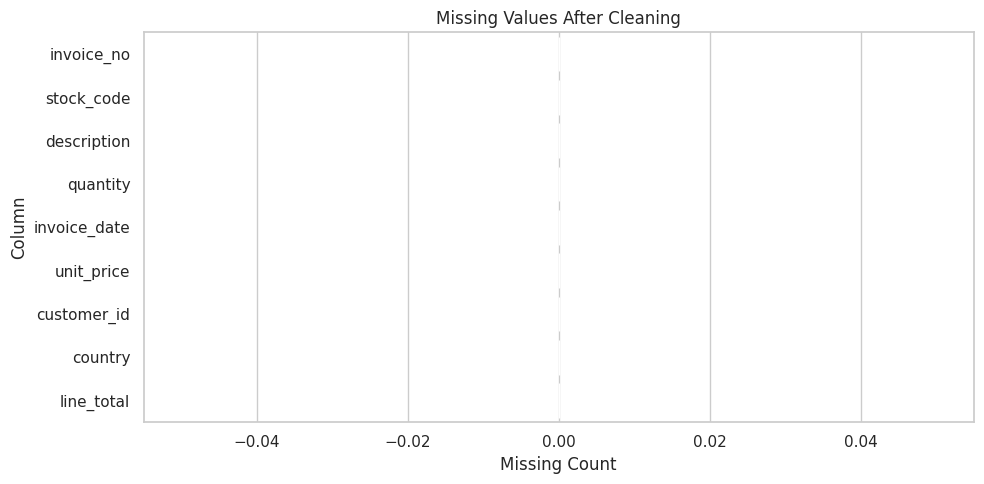

In [9]:
missing_values_df = clean_df.isna().sum().reset_index()
missing_values_df.columns = ["column", "missing_count"]
missing_values_df["missing_percentage"] = missing_values_df["missing_count"] / len(clean_df)
missing_values_df = missing_values_df.sort_values("missing_count", ascending=False)

display(missing_values_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_values_df, x="missing_count", y="column")
plt.title("Missing Values After Cleaning")
plt.xlabel("Missing Count")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [10]:
monthly_summary = (
    clean_df
    .assign(invoice_month=clean_df["invoice_date"].dt.to_period("M").astype(str))
    .groupby("invoice_month", as_index=False)
    .agg(
        revenue=("line_total", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
        quantity=("quantity", "sum"),
        products=("stock_code", "nunique")
    )
)

monthly_summary.head()

,invoice_month,revenue,orders,customers,quantity,products
0,2009-12,683504.010,1512,955,398660,2725
1,2010-01,555802.672,1011,720,370082,2368
2,2010-02,504558.956,1104,772,371861,2374
3,2010-03,696978.471,1524,1057,502100,2668
4,2010-04,591982.002,1329,942,350587,2340


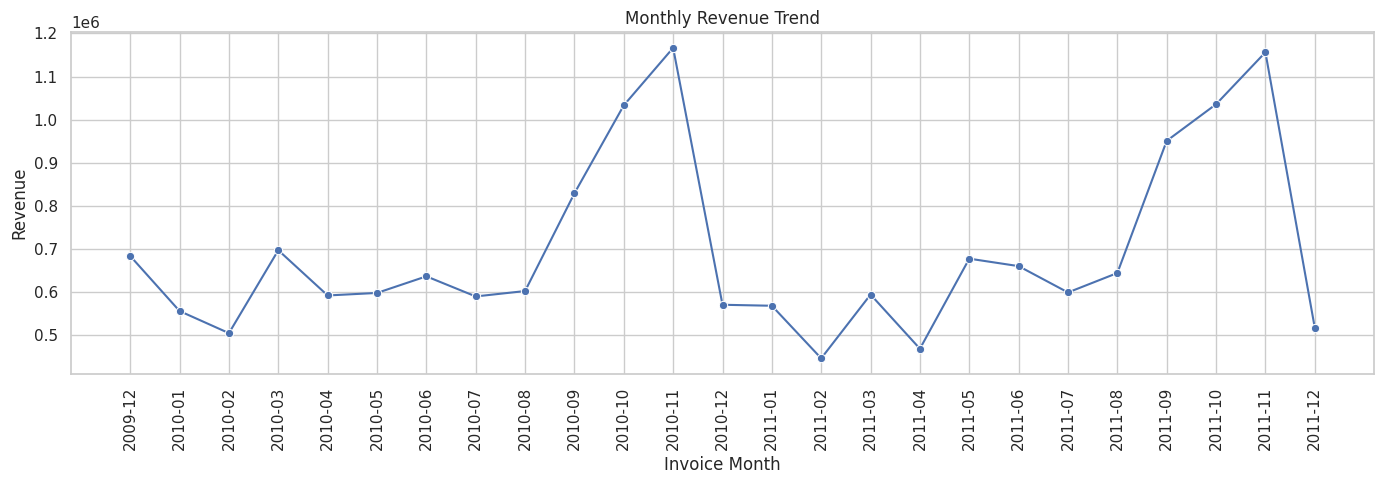

In [11]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_summary, x="invoice_month", y="revenue", marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Invoice Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

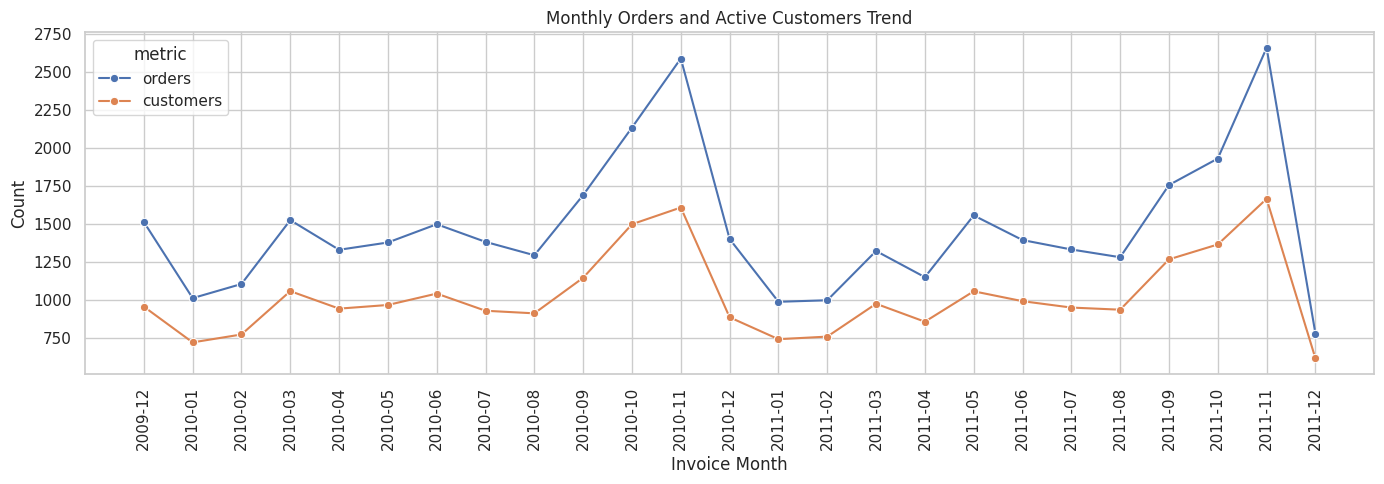

In [12]:
monthly_orders_customers = monthly_summary.melt(
    id_vars="invoice_month",
    value_vars=["orders", "customers"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_orders_customers, x="invoice_month", y="value", hue="metric", marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Orders and Active Customers Trend")
plt.xlabel("Invoice Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

,country,revenue,orders,customers,quantity
38,United Kingdom,1.438923e+07,33541,5350,8532411
10,EIRE,6.165705e+05,567,5,318021
24,Netherlands,5.540381e+05,228,22,383879
14,Germany,4.250197e+05,789,107,225154
13,France,3.487690e+05,614,95,270288
0,Australia,1.692835e+05,95,15,103759
32,Spain,1.083325e+05,154,41,50307
34,Switzerland,1.000619e+05,90,22,52227
33,Sweden,9.151582e+04,104,19,88495
9,Denmark,6.858069e+04,43,12,237471


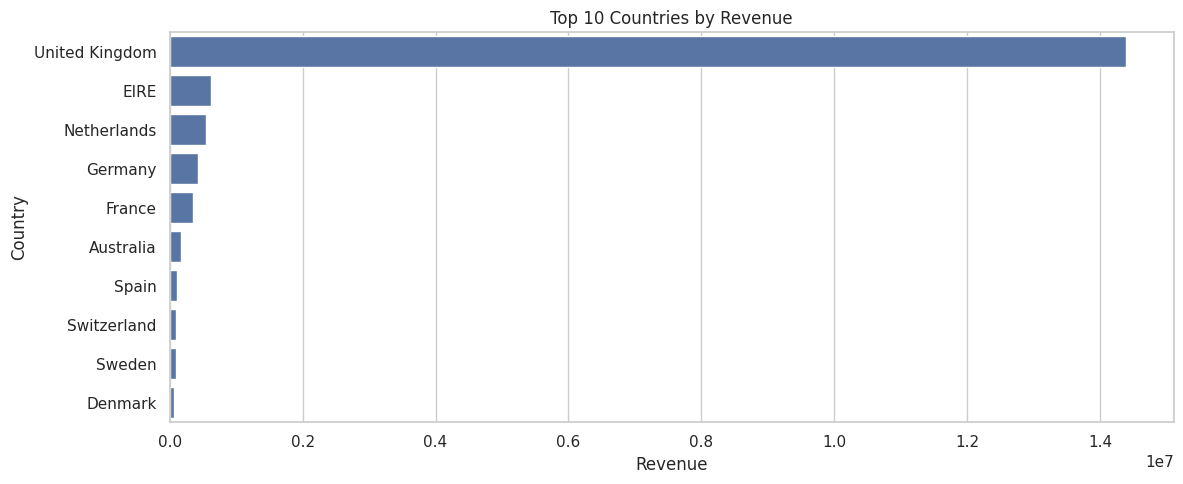

In [13]:
country_summary = (
    clean_df
    .groupby("country", as_index=False)
    .agg(
        revenue=("line_total", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

display(country_summary.head(15))

top_countries = country_summary.head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x="revenue", y="country")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

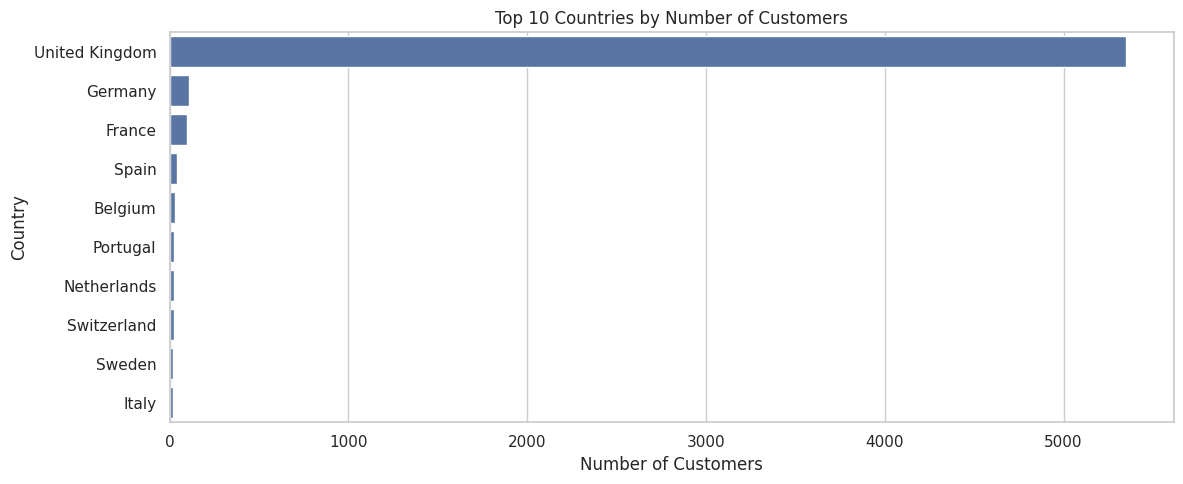

In [14]:
top_customer_countries = country_summary.sort_values("customers", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_customer_countries, x="customers", y="country")
plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

,stock_code,description,revenue,quantity,orders,customers
1846,22423,REGENCY CAKESTAND 3 TIER,277656.25,24124,3317,1314
4723,85123A,WHITE HANGING HEART T-LIGHT HOLDER,247048.01,91757,4888,1490
3263,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1
5280,M,Manual,151777.67,9384,620,438
4698,85099B,JUMBO BAG RED RETROSPOT,134307.44,74224,2612,860
5282,POST,POSTAGE,124648.04,5235,1803,405
4429,84879,ASSORTED COLOUR BIRD ORNAMENT,124351.86,78234,2652,1010
3606,47566,PARTY BUNTING,103283.38,23460,2077,894
2761,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,138
1437,22086,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18,28380,1691,896


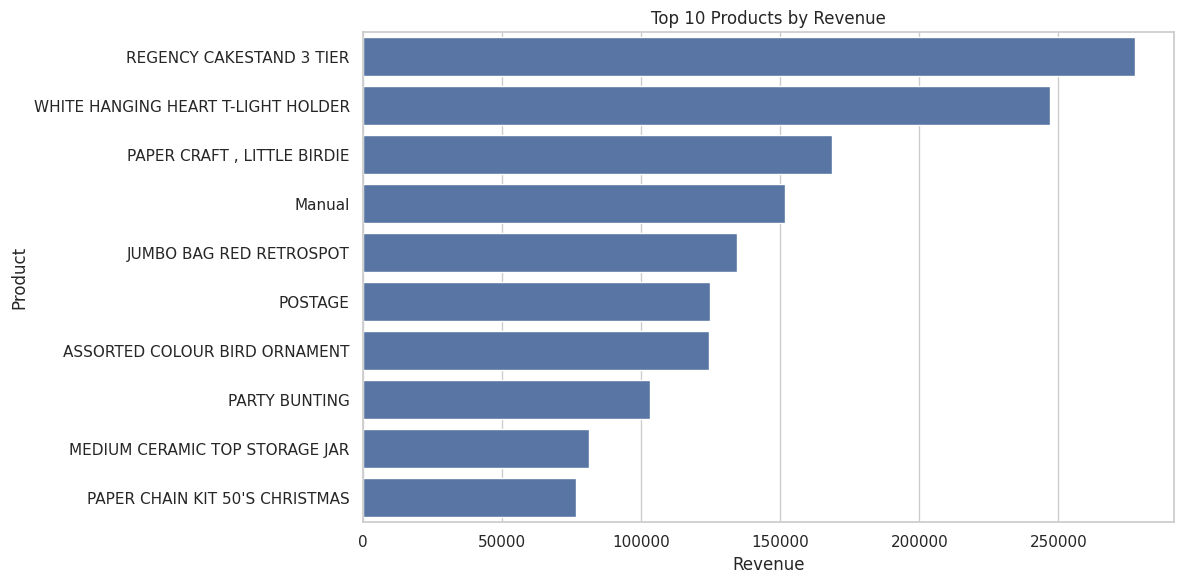

In [15]:
product_summary = (
    clean_df
    .groupby(["stock_code", "description"], as_index=False)
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

display(product_summary.head(20))

top_products = product_summary.head(10).copy()
top_products["product_label"] = top_products["description"].str.slice(0, 40)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x="revenue", y="product_label")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

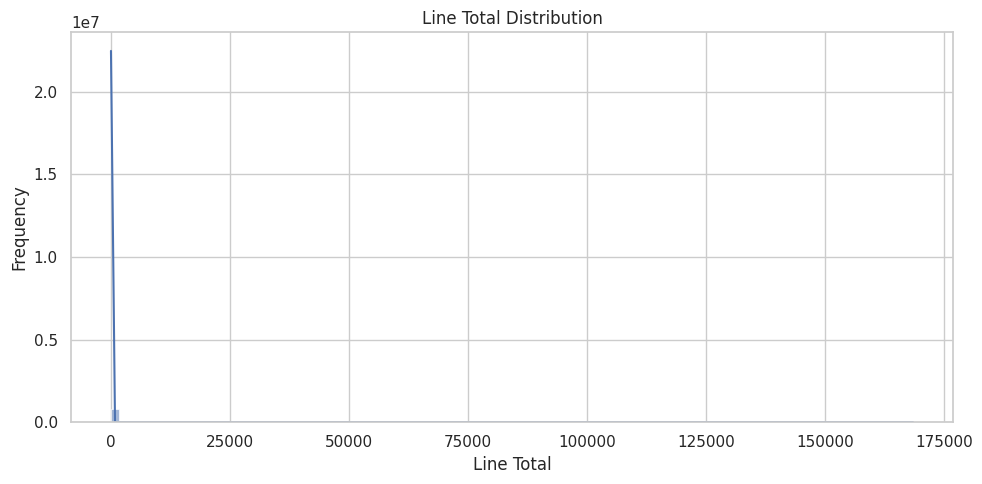

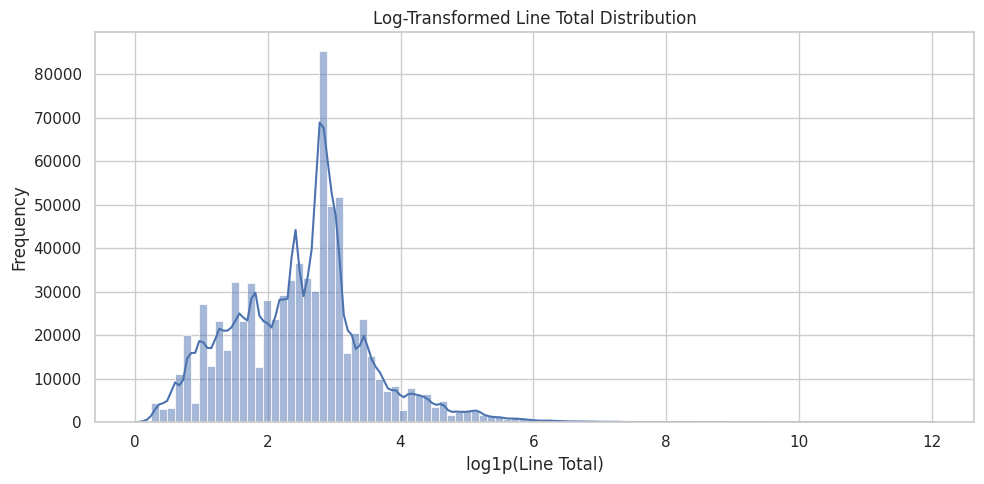

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df["line_total"], bins=100, kde=True)
plt.title("Line Total Distribution")
plt.xlabel("Line Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(clean_df["line_total"]), bins=100, kde=True)
plt.title("Log-Transformed Line Total Distribution")
plt.xlabel("log1p(Line Total)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

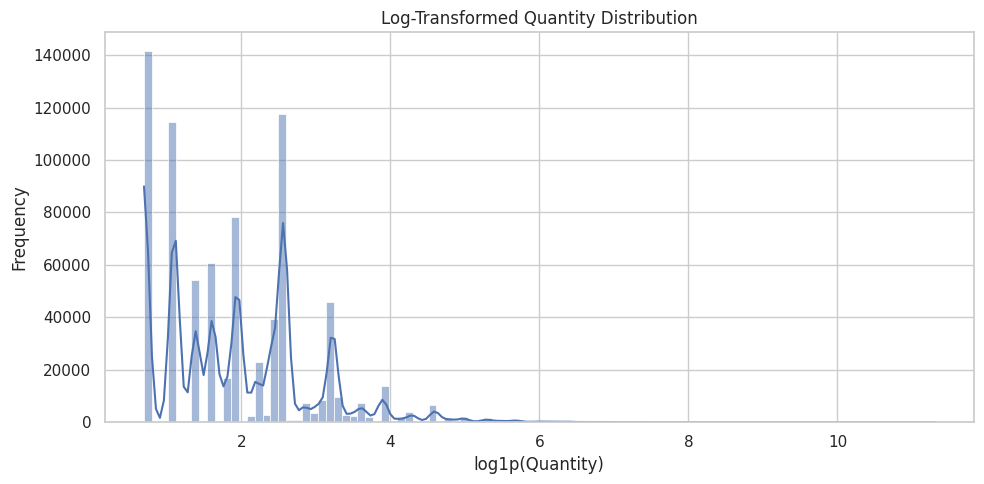

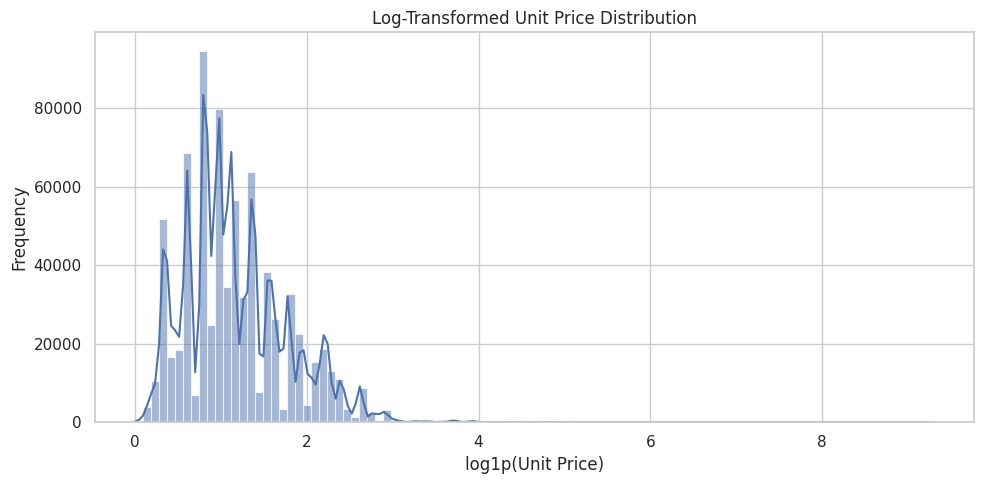

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(clean_df["quantity"]), bins=100, kde=True)
plt.title("Log-Transformed Quantity Distribution")
plt.xlabel("log1p(Quantity)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(clean_df["unit_price"]), bins=100, kde=True)
plt.title("Log-Transformed Unit Price Distribution")
plt.xlabel("log1p(Unit Price)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
invoice_df = (
    clean_df
    .groupby(["customer_id", "invoice_no"], as_index=False)
    .agg(
        invoice_date=("invoice_date", "min"),
        country=("country", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]),
        invoice_revenue=("line_total", "sum"),
        invoice_quantity=("quantity", "sum"),
        unique_products=("stock_code", "nunique"),
        total_lines=("stock_code", "count")
    )
)

invoice_df["invoice_month"] = invoice_df["invoice_date"].dt.to_period("M").astype(str)
invoice_df["avg_item_price"] = invoice_df["invoice_revenue"] / invoice_df["invoice_quantity"].replace(0, np.nan)
invoice_df["avg_line_value"] = invoice_df["invoice_revenue"] / invoice_df["total_lines"].replace(0, np.nan)
invoice_df = invoice_df.sort_values(["customer_id", "invoice_date"]).reset_index(drop=True)

print("Invoice-level shape:", invoice_df.shape)
invoice_df.head()

Invoice-level shape: (36969, 11)


,customer_id,invoice_no,invoice_date,country,invoice_revenue,invoice_quantity,unique_products,total_lines,invoice_month,avg_item_price,avg_line_value
0,12346,491725,2009-12-14 08:34:00,United Kingdom,45.0,10,1,1,2009-12,4.5,45.0
1,12346,491742,2009-12-14 11:00:00,United Kingdom,22.5,5,1,1,2009-12,4.5,22.5
2,12346,491744,2009-12-14 11:02:00,United Kingdom,22.5,5,1,1,2009-12,4.5,22.5
3,12346,492718,2009-12-18 10:47:00,United Kingdom,22.5,5,1,1,2009-12,4.5,22.5
4,12346,492722,2009-12-18 10:55:00,United Kingdom,1.0,1,1,1,2009-12,1.0,1.0


,invoice_revenue,invoice_quantity,unique_products,total_lines
count,36969.000000,36969.000000,36969.000000,36969.000000
mean,469.983074,284.399145,20.797560,21.083205
std,1359.741927,1232.382259,22.399873,22.964763
min,0.380000,1.000000,1.000000,1.000000
25%,157.920000,72.000000,6.000000,6.000000
50%,303.040000,151.000000,15.000000,15.000000
75%,477.280000,287.000000,27.000000,27.000000
max,168469.600000,87167.000000,541.000000,542.000000


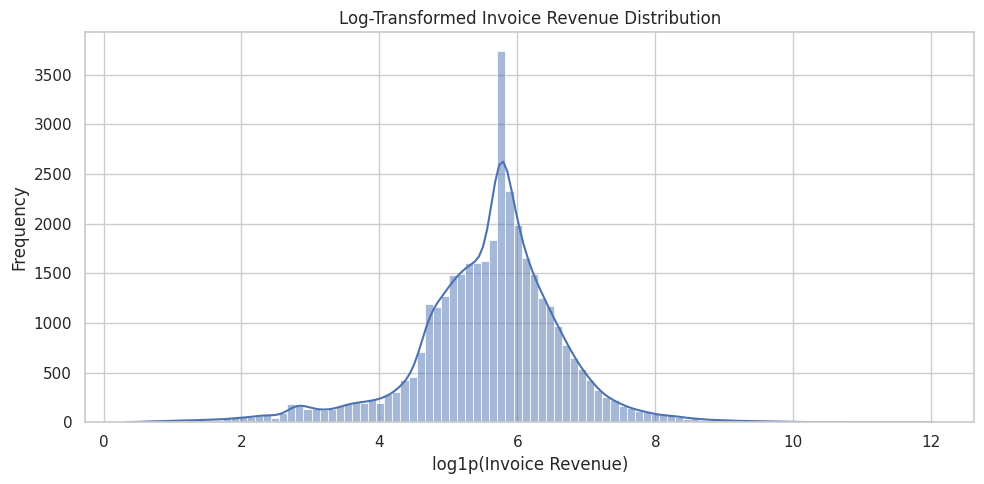

In [19]:
display(invoice_df[["invoice_revenue", "invoice_quantity", "unique_products", "total_lines"]].describe())

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(invoice_df["invoice_revenue"]), bins=100, kde=True)
plt.title("Log-Transformed Invoice Revenue Distribution")
plt.xlabel("log1p(Invoice Revenue)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [20]:
customer_summary = (
    invoice_df
    .groupby("customer_id", as_index=False)
    .agg(
        total_orders=("invoice_no", "nunique"),
        total_revenue=("invoice_revenue", "sum"),
        total_quantity=("invoice_quantity", "sum"),
        avg_order_value=("invoice_revenue", "mean"),
        max_order_value=("invoice_revenue", "max"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        country=("country", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    )
)

customer_summary["customer_lifetime_days"] = (
    customer_summary["last_purchase"] - customer_summary["first_purchase"]
).dt.days

customer_summary["recency_from_dataset_end"] = (
    invoice_df["invoice_date"].max() - customer_summary["last_purchase"]
).dt.days

customer_summary["orders_per_lifetime_day"] = (
    customer_summary["total_orders"] / customer_summary["customer_lifetime_days"].replace(0, 1)
)

customer_summary.head()

,customer_id,total_orders,total_revenue,total_quantity,avg_order_value,max_order_value,first_purchase,last_purchase,country,customer_lifetime_days,recency_from_dataset_end,orders_per_lifetime_day
0,12346,12,77556.46,74285,6463.038333,77183.60,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,400,325,0.030000
1,12347,8,4921.53,2967,615.191250,1294.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,402,1,0.019900
2,12348,5,2019.40,2714,403.880000,892.80,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,362,74,0.013812
3,12349,4,4428.69,1624,1107.172500,1757.55,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,570,18,0.007018
4,12350,1,334.40,197,334.400000,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,0,309,1.000000


In [21]:
customer_summary[
    [
        "total_orders",
        "total_revenue",
        "total_quantity",
        "avg_order_value",
        "max_order_value",
        "customer_lifetime_days",
        "recency_from_dataset_end",
        "orders_per_lifetime_day"
    ]
].describe()

,total_orders,total_revenue,total_quantity,avg_order_value,max_order_value,customer_lifetime_days,recency_from_dataset_end,orders_per_lifetime_day
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,6.289384,2955.904095,1788.695475,385.180841,679.390904,273.022457,200.331916,0.329212
std,13.009406,14440.852688,8876.297196,1214.286459,2785.873110,258.807591,209.338707,0.495084
min,1.000000,2.950000,1.000000,2.950000,2.950000,0.000000,0.000000,0.002801
25%,1.000000,342.280000,187.000000,176.682500,231.960000,0.000000,25.000000,0.013143
50%,3.000000,867.740000,480.000000,279.242679,384.870000,220.500000,95.000000,0.027288
75%,7.000000,2248.305000,1350.000000,414.902458,662.200000,511.000000,379.000000,1.000000
max,398.000000,580987.040000,367193.000000,84236.250000,168469.600000,738.000000,738.000000,6.000000


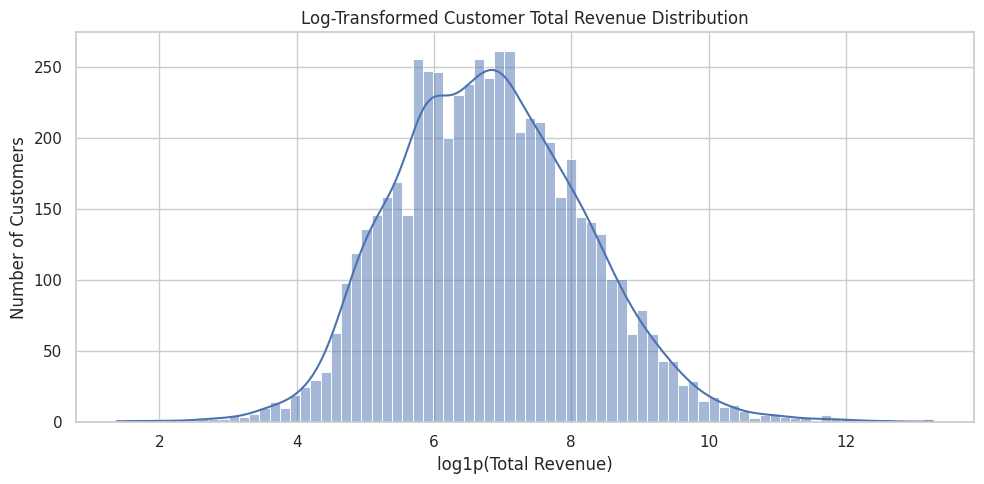

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(customer_summary["total_revenue"]), bins=80, kde=True)
plt.title("Log-Transformed Customer Total Revenue Distribution")
plt.xlabel("log1p(Total Revenue)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

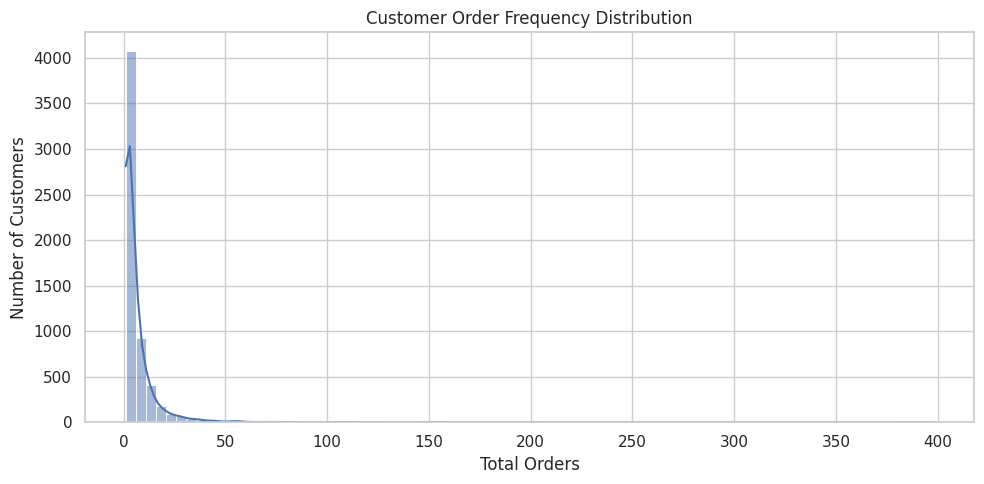

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(customer_summary["total_orders"], bins=80, kde=True)
plt.title("Customer Order Frequency Distribution")
plt.xlabel("Total Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

,customer_type,count,percentage
0,repeat_customer,4255,0.723886
1,one_time_customer,1623,0.276114


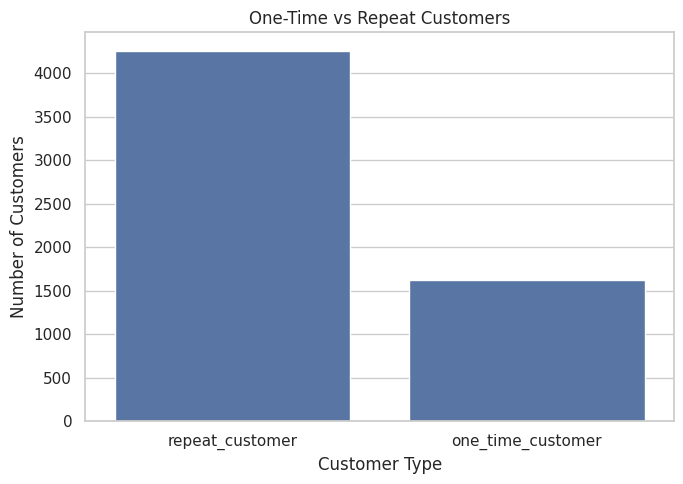

In [24]:
customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] == 1,
    "one_time_customer",
    "repeat_customer"
)

customer_type_distribution = customer_summary["customer_type"].value_counts().reset_index()
customer_type_distribution.columns = ["customer_type", "count"]
customer_type_distribution["percentage"] = customer_type_distribution["count"] / customer_type_distribution["count"].sum()

display(customer_type_distribution)

plt.figure(figsize=(7, 5))
sns.barplot(data=customer_type_distribution, x="customer_type", y="count")
plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

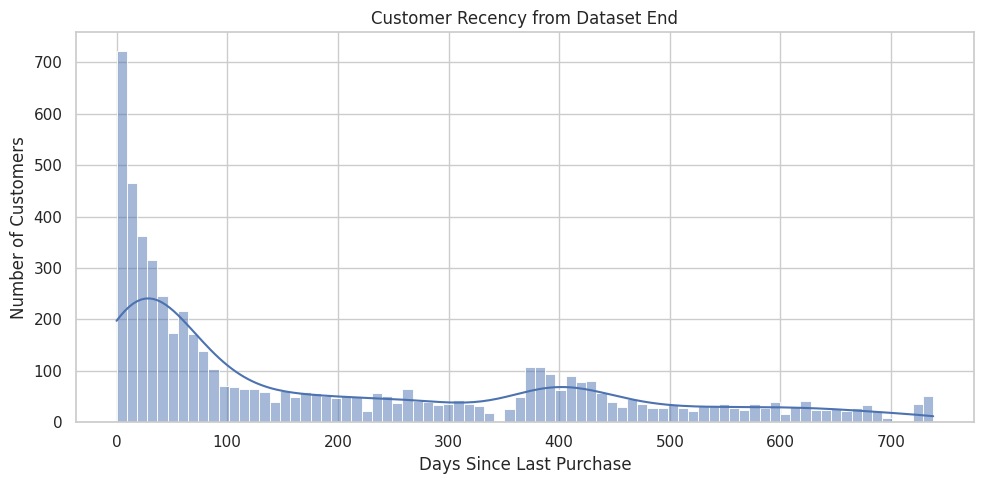

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(customer_summary["recency_from_dataset_end"], bins=80, kde=True)
plt.title("Customer Recency from Dataset End")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [26]:
min_date = invoice_df["invoice_date"].min()
max_date = invoice_df["invoice_date"].max()

first_snapshot = min_date + pd.Timedelta(days=HISTORY_WINDOW_DAYS)
last_snapshot = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)

snapshot_dates = pd.date_range(
    start=first_snapshot,
    end=last_snapshot,
    freq=SNAPSHOT_FREQUENCY
)

snapshot_dates = pd.to_datetime(snapshot_dates)

print("Minimum transaction date:", min_date)
print("Maximum transaction date:", max_date)
print("First snapshot date:", first_snapshot)
print("Last snapshot date:", last_snapshot)
print("Number of snapshots:", len(snapshot_dates))

snapshot_dates[:5]

Minimum transaction date: 2009-12-01 07:45:00
Maximum transaction date: 2011-12-09 12:50:00
First snapshot date: 2010-05-30 07:45:00
Last snapshot date: 2011-09-10 12:50:00
Number of snapshots: 16


DatetimeIndex(['2010-06-01 07:45:00', '2010-07-01 07:45:00',
               '2010-08-01 07:45:00', '2010-09-01 07:45:00',
               '2010-10-01 07:45:00'],
              dtype='datetime64[ns]', freq='MS')

In [27]:
def safe_divide(numerator, denominator, default_value=0.0):
    """
    Divide values safely and return a default value when denominator is zero.
    """
    if denominator == 0 or pd.isna(denominator):
        return default_value
    return numerator / denominator

def build_features_for_snapshot(invoice_table, snapshot_date, churn_window_days, history_window_days):
    """
    Build customer-level features and churn labels for one historical snapshot.

    Feature rule:
    Only transactions before or on the snapshot date are used as features.

    Label rule:
    Transactions after the snapshot date are used only to define churn.
    """
    snapshot_date = pd.Timestamp(snapshot_date)

    history_start = snapshot_date - pd.Timedelta(days=history_window_days)
    recent_start = snapshot_date - pd.Timedelta(days=history_window_days // 2)
    future_end = snapshot_date + pd.Timedelta(days=churn_window_days)

    history_all = invoice_table[invoice_table["invoice_date"] <= snapshot_date].copy()

    history_window = invoice_table[
        (invoice_table["invoice_date"] > history_start) &
        (invoice_table["invoice_date"] <= snapshot_date)
    ].copy()

    recent_window = invoice_table[
        (invoice_table["invoice_date"] > recent_start) &
        (invoice_table["invoice_date"] <= snapshot_date)
    ].copy()

    previous_window = invoice_table[
        (invoice_table["invoice_date"] > history_start) &
        (invoice_table["invoice_date"] <= recent_start)
    ].copy()

    future_window = invoice_table[
        (invoice_table["invoice_date"] > snapshot_date) &
        (invoice_table["invoice_date"] <= future_end)
    ].copy()

    if history_window.empty:
        return pd.DataFrame()

    base_window = (
        history_window
        .groupby("customer_id", as_index=False)
        .agg(
            orders_last_window=("invoice_no", "nunique"),
            revenue_last_window=("invoice_revenue", "sum"),
            quantity_last_window=("invoice_quantity", "sum"),
            product_slots_last_window=("unique_products", "sum"),
            lines_last_window=("total_lines", "sum"),
            avg_order_value_last_window=("invoice_revenue", "mean"),
            max_order_value_last_window=("invoice_revenue", "max"),
            min_order_value_last_window=("invoice_revenue", "min"),
            std_order_value_last_window=("invoice_revenue", "std"),
            avg_quantity_per_order_last_window=("invoice_quantity", "mean"),
            avg_products_per_order_last_window=("unique_products", "mean"),
            avg_lines_per_order_last_window=("total_lines", "mean"),
            first_purchase_window=("invoice_date", "min"),
            last_purchase_window=("invoice_date", "max"),
            country=("country", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
        )
    )

    all_time = (
        history_all
        .groupby("customer_id", as_index=False)
        .agg(
            orders_all_time=("invoice_no", "nunique"),
            revenue_all_time=("invoice_revenue", "sum"),
            quantity_all_time=("invoice_quantity", "sum"),
            product_slots_all_time=("unique_products", "sum"),
            lines_all_time=("total_lines", "sum"),
            avg_order_value_all_time=("invoice_revenue", "mean"),
            max_order_value_all_time=("invoice_revenue", "max"),
            min_order_value_all_time=("invoice_revenue", "min"),
            std_order_value_all_time=("invoice_revenue", "std"),
            first_purchase_all_time=("invoice_date", "min"),
            last_purchase_all_time=("invoice_date", "max")
        )
    )

    recent_features = (
        recent_window
        .groupby("customer_id", as_index=False)
        .agg(
            recent_orders=("invoice_no", "nunique"),
            recent_revenue=("invoice_revenue", "sum")
        )
    )

    previous_features = (
        previous_window
        .groupby("customer_id", as_index=False)
        .agg(
            previous_orders=("invoice_no", "nunique"),
            previous_revenue=("invoice_revenue", "sum")
        )
    )

    future_orders = (
        future_window
        .groupby("customer_id", as_index=False)
        .agg(future_orders=("invoice_no", "nunique"))
    )

    features = base_window.merge(all_time, on="customer_id", how="left")
    features = features.merge(recent_features, on="customer_id", how="left")
    features = features.merge(previous_features, on="customer_id", how="left")
    features = features.merge(future_orders, on="customer_id", how="left")

    fill_zero_cols = [
        "recent_orders",
        "recent_revenue",
        "previous_orders",
        "previous_revenue",
        "future_orders"
    ]

    for col in fill_zero_cols:
        features[col] = features[col].fillna(0)

    features["churn"] = (features["future_orders"] == 0).astype(int)
    features["snapshot_date"] = snapshot_date

    features["recency_days"] = (snapshot_date - features["last_purchase_all_time"]).dt.days
    features["customer_age_days"] = (snapshot_date - features["first_purchase_all_time"]).dt.days
    features["active_span_days"] = (
        features["last_purchase_all_time"] - features["first_purchase_all_time"]
    ).dt.days
    features["window_active_span_days"] = (
        features["last_purchase_window"] - features["first_purchase_window"]
    ).dt.days

    features["avg_days_between_orders"] = features.apply(
        lambda row: safe_divide(row["active_span_days"], max(row["orders_all_time"] - 1, 1)),
        axis=1
    )

    features["order_frequency_all_time"] = features.apply(
        lambda row: safe_divide(row["orders_all_time"], max(row["customer_age_days"], 1)),
        axis=1
    )

    features["revenue_per_day_all_time"] = features.apply(
        lambda row: safe_divide(row["revenue_all_time"], max(row["customer_age_days"], 1)),
        axis=1
    )

    features["orders_per_active_day_window"] = features.apply(
        lambda row: safe_divide(row["orders_last_window"], max(row["window_active_span_days"], 1)),
        axis=1
    )

    features["revenue_per_order_all_time"] = features.apply(
        lambda row: safe_divide(row["revenue_all_time"], row["orders_all_time"]),
        axis=1
    )

    features["quantity_per_order_all_time"] = features.apply(
        lambda row: safe_divide(row["quantity_all_time"], row["orders_all_time"]),
        axis=1
    )

    features["monetary_ratio_window_to_all"] = features.apply(
        lambda row: safe_divide(row["revenue_last_window"], row["revenue_all_time"]),
        axis=1
    )

    features["order_ratio_window_to_all"] = features.apply(
        lambda row: safe_divide(row["orders_last_window"], row["orders_all_time"]),
        axis=1
    )

    features["purchase_acceleration"] = features.apply(
        lambda row: safe_divide(row["recent_orders"], max(row["previous_orders"], 1)),
        axis=1
    )

    features["revenue_acceleration"] = features.apply(
        lambda row: safe_divide(row["recent_revenue"], max(row["previous_revenue"], 1)),
        axis=1
    )

    features["recent_vs_previous_order_ratio"] = features["purchase_acceleration"]
    features["recent_vs_previous_revenue_ratio"] = features["revenue_acceleration"]

    features["recency_to_age_ratio"] = features.apply(
        lambda row: safe_divide(row["recency_days"], max(row["customer_age_days"], 1)),
        axis=1
    )

    features["is_one_time_customer"] = (features["orders_all_time"] == 1).astype(int)
    features["is_repeat_customer"] = (features["orders_all_time"] > 1).astype(int)

    features["log_revenue_last_window"] = np.log1p(features["revenue_last_window"])
    features["log_revenue_all_time"] = np.log1p(features["revenue_all_time"])
    features["log_avg_order_value_last_window"] = np.log1p(features["avg_order_value_last_window"])

    features["snapshot_month"] = features["snapshot_date"].dt.month
    features["snapshot_quarter"] = features["snapshot_date"].dt.quarter

    features["std_order_value_last_window"] = features["std_order_value_last_window"].fillna(0)
    features["std_order_value_all_time"] = features["std_order_value_all_time"].fillna(0)

    features = features[features["orders_last_window"] >= MIN_HISTORY_ORDERS].copy()

    date_cols = [
        "first_purchase_window",
        "last_purchase_window",
        "first_purchase_all_time",
        "last_purchase_all_time"
    ]

    features = features.drop(columns=date_cols)

    return features

In [28]:
snapshot_frames = []

for snapshot_date in snapshot_dates:
    snapshot_df = build_features_for_snapshot(
        invoice_table=invoice_df,
        snapshot_date=snapshot_date,
        churn_window_days=CHURN_WINDOW_DAYS,
        history_window_days=HISTORY_WINDOW_DAYS
    )

    if not snapshot_df.empty:
        snapshot_frames.append(snapshot_df)

if len(snapshot_frames) == 0:
    raise ValueError("No snapshot dataset could be created. Try reducing HISTORY_WINDOW_DAYS or CHURN_WINDOW_DAYS.")

churn_df = pd.concat(snapshot_frames, ignore_index=True)
churn_df = churn_df.sort_values(["snapshot_date", "customer_id"]).reset_index(drop=True)

print("Churn dataset shape:", churn_df.shape)
print("Snapshot range:", churn_df["snapshot_date"].min(), "to", churn_df["snapshot_date"].max())
print("Unique customers:", churn_df["customer_id"].nunique())
print("Churn rate:", churn_df["churn"].mean())

churn_df.head()

Churn dataset shape: (48079, 54)
Snapshot range: 2010-06-01 07:45:00 to 2011-09-01 07:45:00
Unique customers: 5236
Churn rate: 0.5093907943176855


,customer_id,orders_last_window,revenue_last_window,quantity_last_window,product_slots_last_window,lines_last_window,avg_order_value_last_window,max_order_value_last_window,min_order_value_last_window,std_order_value_last_window,avg_quantity_per_order_last_window,avg_products_per_order_last_window,avg_lines_per_order_last_window,country,orders_all_time,revenue_all_time,quantity_all_time,product_slots_all_time,lines_all_time,avg_order_value_all_time,max_order_value_all_time,min_order_value_all_time,std_order_value_all_time,recent_orders,recent_revenue,previous_orders,previous_revenue,future_orders,churn,snapshot_date,recency_days,customer_age_days,active_span_days,window_active_span_days,avg_days_between_orders,order_frequency_all_time,revenue_per_day_all_time,orders_per_active_day_window,revenue_per_order_all_time,quantity_per_order_all_time,monetary_ratio_window_to_all,order_ratio_window_to_all,purchase_acceleration,revenue_acceleration,recent_vs_previous_order_ratio,recent_vs_previous_revenue_ratio,recency_to_age_ratio,is_one_time_customer,is_repeat_customer,log_revenue_last_window,log_revenue_all_time,log_avg_order_value_last_window,snapshot_month,snapshot_quarter
0,12346,10,230.55,51,14,14,23.0550,45.00,1.00,10.467528,5.10,1.4,1.4,United Kingdom,10,230.55,51,14,14,23.0550,45.00,1.00,10.467528,0.0,0.00,10.0,230.55,1.0,0,2010-06-01 07:45:00,90,168,78,78,8.666667,0.059524,1.372321,0.128205,23.0550,5.10,1.0,1.0,0.0,0.000000,0.0,0.000000,0.535714,0,1,5.444796,5.444796,3.180343,6,2
1,12349,2,1268.52,474,47,47,634.2600,1068.52,200.00,614.136382,237.00,23.5,23.5,Italy,2,1268.52,474,47,47,634.2600,1068.52,200.00,614.136382,2.0,1268.52,0.0,0.00,0.0,1,2010-06-01 07:45:00,13,32,18,18,18.000000,0.062500,39.641250,0.111111,634.2600,237.00,1.0,1.0,2.0,1268.520000,2.0,1268.520000,0.406250,0,1,7.146394,7.146394,6.454034,6,2
2,12355,1,488.21,303,22,22,488.2100,488.21,488.21,0.000000,303.00,22.0,22.0,Bahrain,1,488.21,303,22,22,488.2100,488.21,488.21,0.000000,1.0,488.21,0.0,0.00,0.0,1,2010-06-01 07:45:00,10,10,0,0,0.000000,0.100000,48.821000,1.000000,488.2100,303.00,1.0,1.0,1.0,488.210000,1.0,488.210000,1.000000,1,0,6.192792,6.192792,6.192792,6,2
3,12358,1,1429.83,309,17,17,1429.8300,1429.83,1429.83,0.000000,309.00,17.0,17.0,Austria,1,1429.83,309,17,17,1429.8300,1429.83,1429.83,0.000000,0.0,0.00,1.0,1429.83,1.0,0,2010-06-01 07:45:00,174,174,0,0,0.000000,0.005747,8.217414,1.000000,1429.8300,309.00,1.0,1.0,0.0,0.000000,0.0,0.000000,1.000000,1,0,7.266010,7.266010,7.266010,6,2
4,12359,4,1522.23,777,66,66,380.5575,760.69,78.20,282.238753,194.25,16.5,16.5,Cyprus,4,1522.23,777,66,66,380.5575,760.69,78.20,282.238753,2.0,683.34,2.0,838.89,1.0,0,2010-06-01 07:45:00,69,177,107,107,35.666667,0.022599,8.600169,0.037383,380.5575,194.25,1.0,1.0,1.0,0.814576,1.0,0.814576,0.389831,0,1,7.328588,7.328588,5.944262,6,2


,churn,count,label,percentage
0,1,24491,churn,0.509391
1,0,23588,not_churn,0.490609


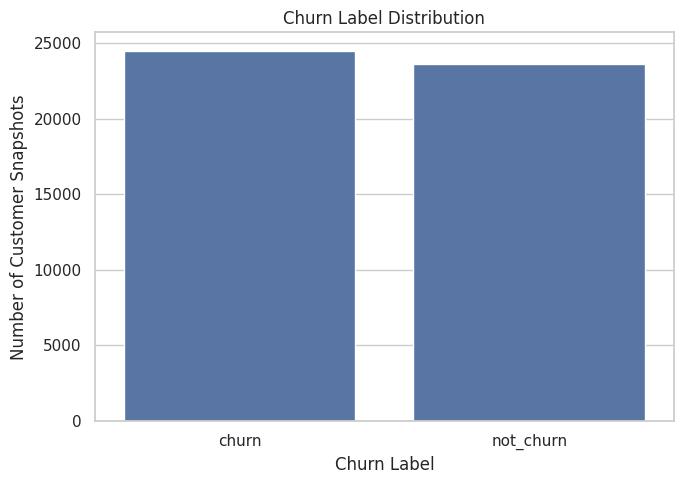

In [29]:
churn_distribution = churn_df["churn"].value_counts().reset_index()
churn_distribution.columns = ["churn", "count"]
churn_distribution["label"] = churn_distribution["churn"].map({0: "not_churn", 1: "churn"})
churn_distribution["percentage"] = churn_distribution["count"] / churn_distribution["count"].sum()

display(churn_distribution)

plt.figure(figsize=(7, 5))
sns.barplot(data=churn_distribution, x="label", y="count")
plt.title("Churn Label Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customer Snapshots")
plt.tight_layout()
plt.show()

,snapshot_date,churn_rate,customer_snapshots
0,2010-06-01 07:45:00,0.500937,2669
1,2010-07-01 07:45:00,0.492564,2757
2,2010-08-01 07:45:00,0.430546,2822
3,2010-09-01 07:45:00,0.380784,2831
4,2010-10-01 07:45:00,0.421993,2910
5,2010-11-01 07:45:00,0.507635,3209
6,2010-12-01 07:45:00,0.620581,3479
7,2011-01-01 07:45:00,0.623426,3415
8,2011-02-01 07:45:00,0.603751,3359
9,2011-03-01 07:45:00,0.577187,3349


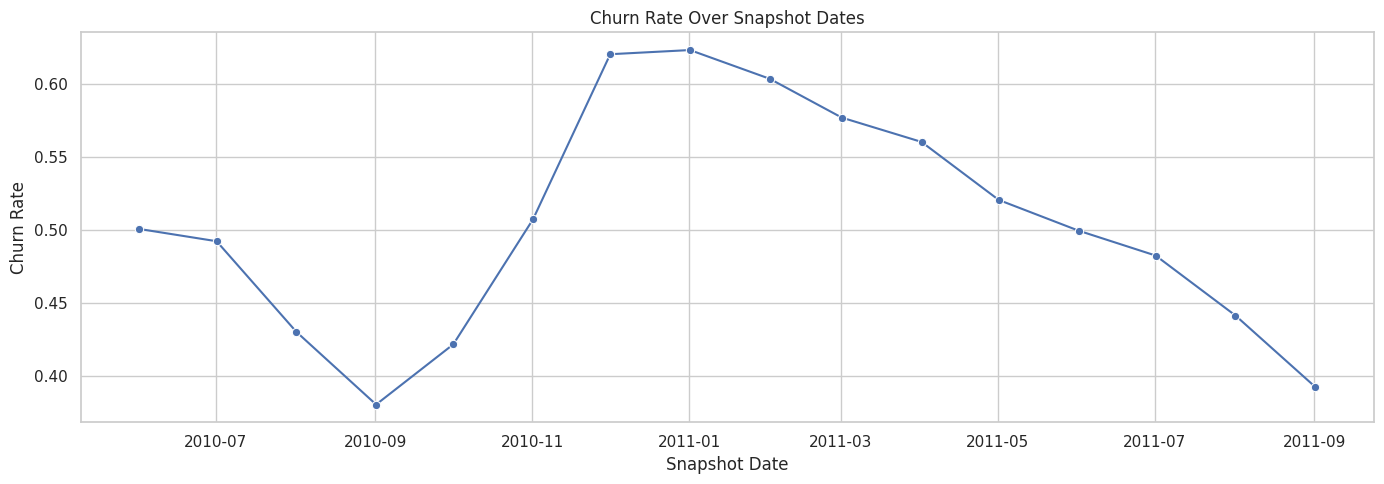

In [30]:
churn_over_time = (
    churn_df
    .groupby("snapshot_date", as_index=False)
    .agg(
        churn_rate=("churn", "mean"),
        customer_snapshots=("customer_id", "count")
    )
)

display(churn_over_time)

plt.figure(figsize=(14, 5))
sns.lineplot(data=churn_over_time, x="snapshot_date", y="churn_rate", marker="o")
plt.title("Churn Rate Over Snapshot Dates")
plt.xlabel("Snapshot Date")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

,country,churn_rate,customer_snapshots,avg_revenue_last_window,avg_recency_days
38,United Kingdom,0.511883,44055,1184.741127,64.910839
14,Germany,0.392567,861,1822.110180,55.902439
13,France,0.352174,690,1730.044362,52.460870
32,Spain,0.552124,259,1453.100000,69.652510
3,Belgium,0.395833,240,865.663375,56.687500
24,Netherlands,0.578431,204,9916.264020,65.887255
34,Switzerland,0.527174,184,2059.607337,66.152174
28,Portugal,0.608434,166,1231.468494,71.210843
0,Australia,0.475524,143,4083.769930,64.720280
33,Sweden,0.601562,128,2908.535859,68.750000


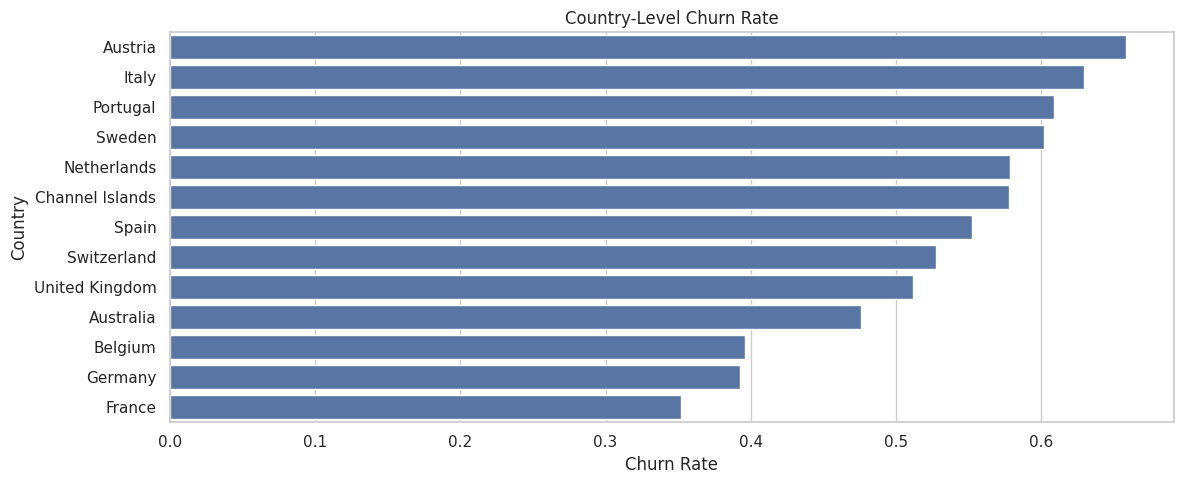

In [31]:
country_churn = (
    churn_df
    .groupby("country", as_index=False)
    .agg(
        churn_rate=("churn", "mean"),
        customer_snapshots=("customer_id", "count"),
        avg_revenue_last_window=("revenue_last_window", "mean"),
        avg_recency_days=("recency_days", "mean")
    )
    .sort_values("customer_snapshots", ascending=False)
)

display(country_churn.head(20))

country_churn_filtered = (
    country_churn[country_churn["customer_snapshots"] >= 100]
    .sort_values("churn_rate", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=country_churn_filtered, x="churn_rate", y="country")
plt.title("Country-Level Churn Rate")
plt.xlabel("Churn Rate")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [32]:
selected_eda_features = [
    "recency_days",
    "orders_last_window",
    "revenue_last_window",
    "orders_all_time",
    "revenue_all_time",
    "customer_age_days",
    "avg_order_value_last_window",
    "purchase_acceleration",
    "revenue_acceleration",
    "recency_to_age_ratio"
]

for feature in selected_eda_features:
    print(f"\nFeature: {feature}")
    display(churn_df.groupby("churn")[feature].describe())


Feature: recency_days


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,23588.0,50.860395,45.398109,0.0,14.0,36.0,77.0,179.0
1,24491.0,78.067413,51.686444,0.0,33.0,73.0,120.0,179.0



Feature: orders_last_window


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,23588.0,4.033704,5.777088,1.0,1.0,3.0,5.0,124.0
1,24491.0,1.743375,1.665813,1.0,1.0,1.0,2.0,91.0



Feature: revenue_last_window


...

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,23588.0,1.115925,1.125385,0.0,0.428571,1.0,1.5,40.0
1,24491.0,0.736598,0.817611,0.0,0.000000,1.0,1.0,11.0



Feature: revenue_acceleration


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,23588.0,174.681426,807.097163,0.0,0.333748,1.062874,28.072722,50393.46
1,24491.0,185.174971,1079.778797,0.0,0.000000,0.784623,206.080000,77183.60



Feature: recency_to_age_ratio


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,23588.0,0.304331,0.335292,0.0,0.054348,0.159639,0.418182,1.0
1,24491.0,0.560097,0.389666,0.0,0.183158,0.481481,1.000000,1.0


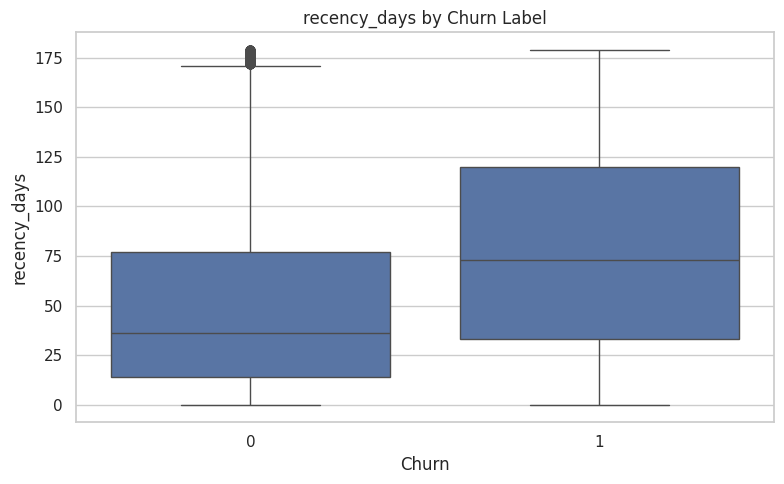

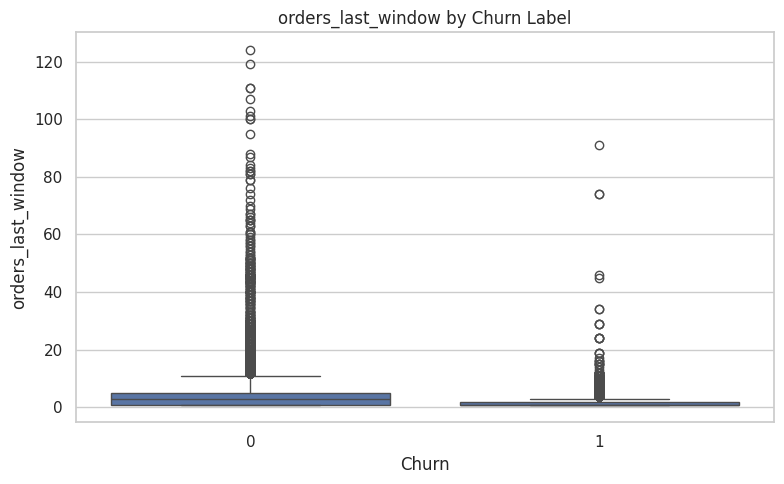

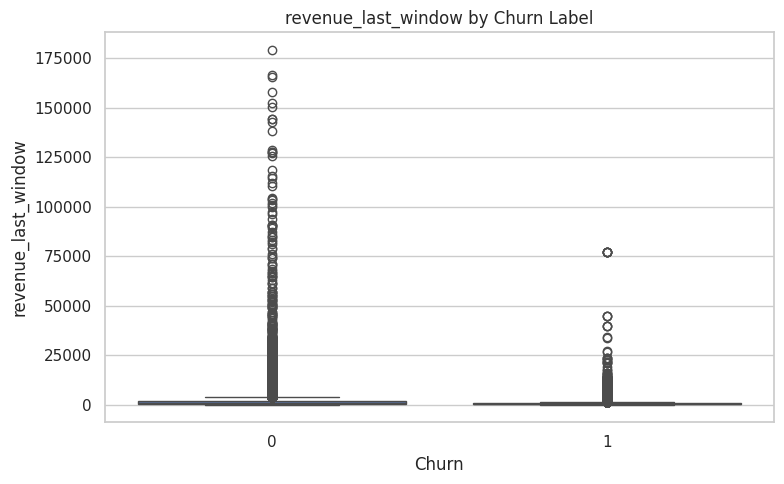

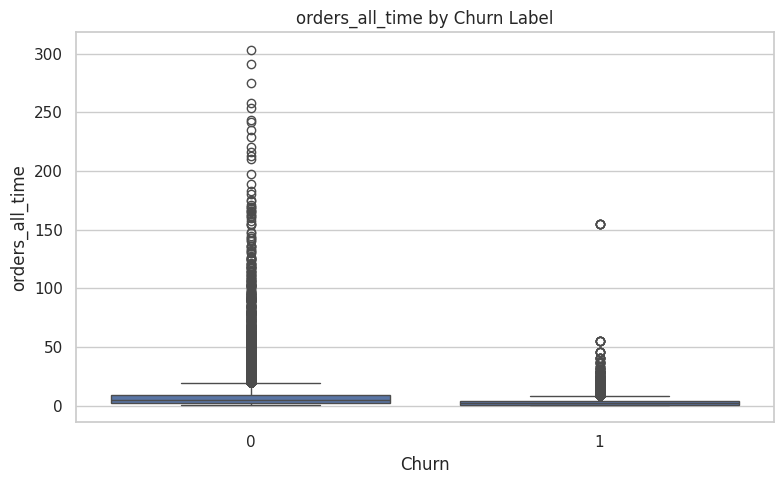

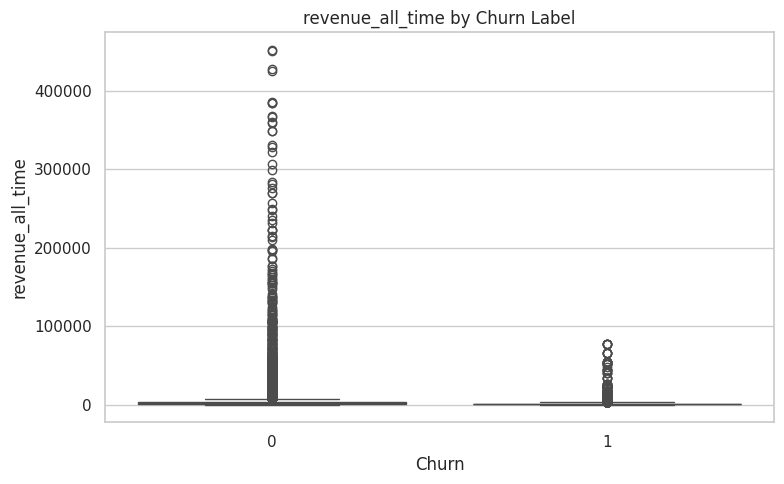

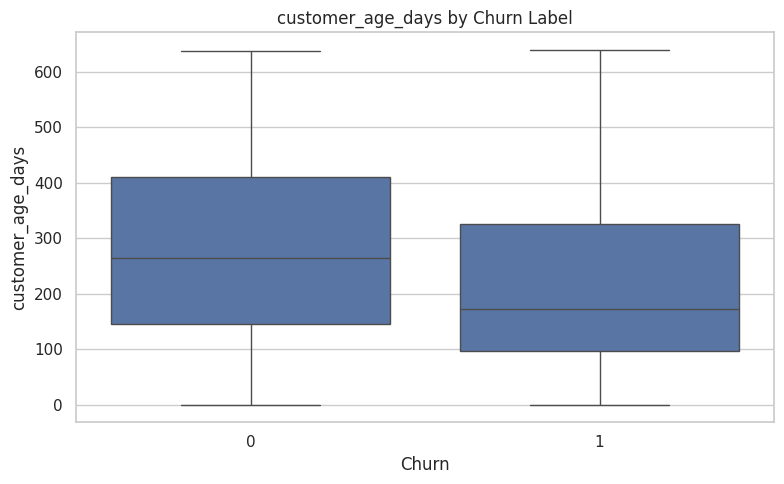

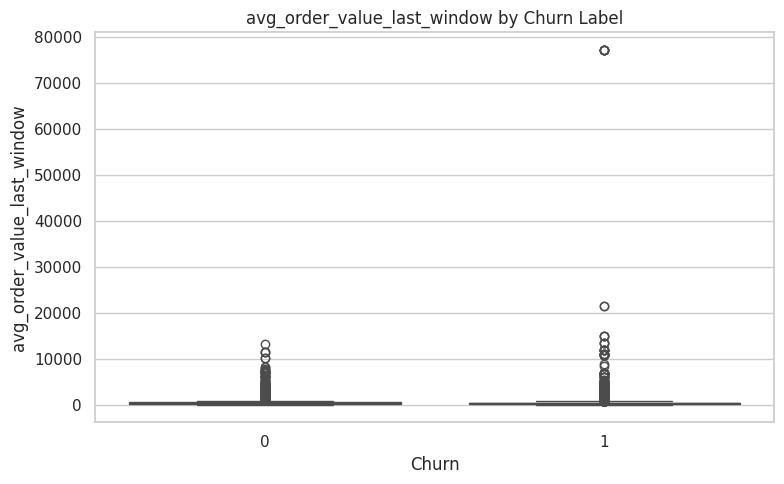

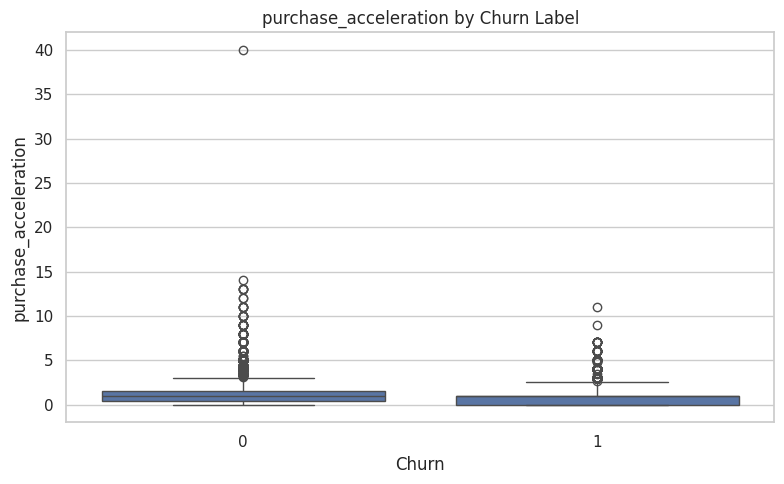

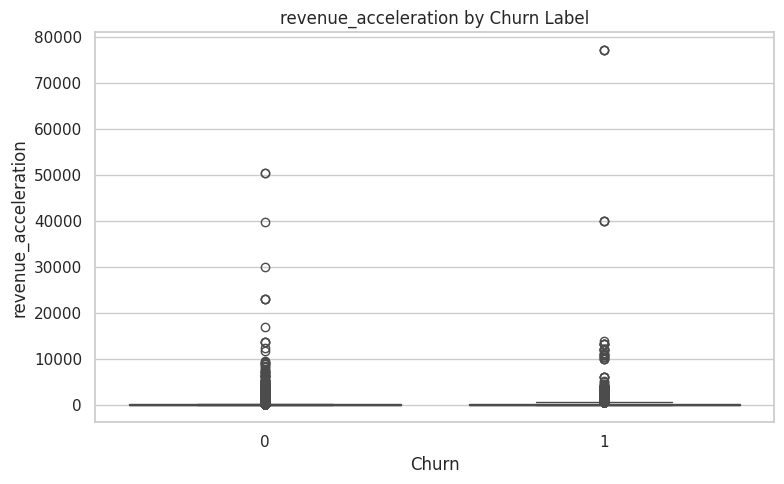

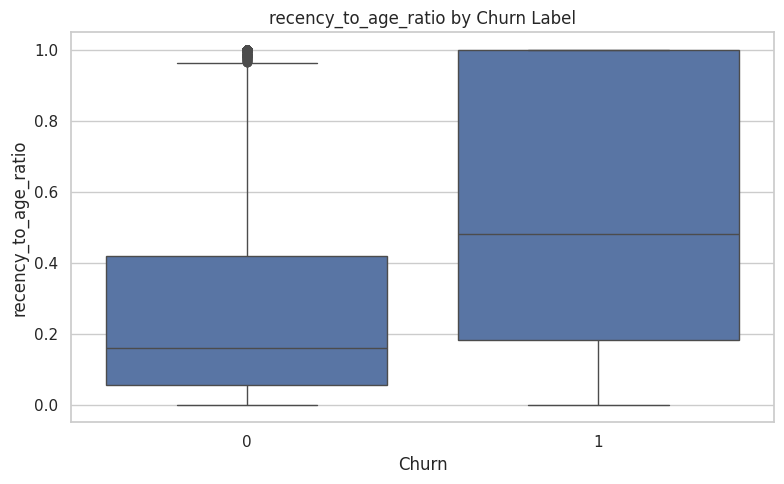

In [33]:
for feature in selected_eda_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=churn_df, x="churn", y=feature)
    plt.title(f"{feature} by Churn Label")
    plt.xlabel("Churn")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

,feature,correlation_with_churn
0,recency_to_age_ratio,0.331415
1,orders_per_active_day_window,0.293756
2,recency_days,0.268980
3,is_one_time_customer,0.258410
4,order_ratio_window_to_all,0.158348
5,monetary_ratio_window_to_all,0.153309
6,min_order_value_all_time,0.073490
7,avg_days_between_orders,0.067563
8,min_order_value_last_window,0.028035
9,recent_vs_previous_revenue_ratio,0.005489


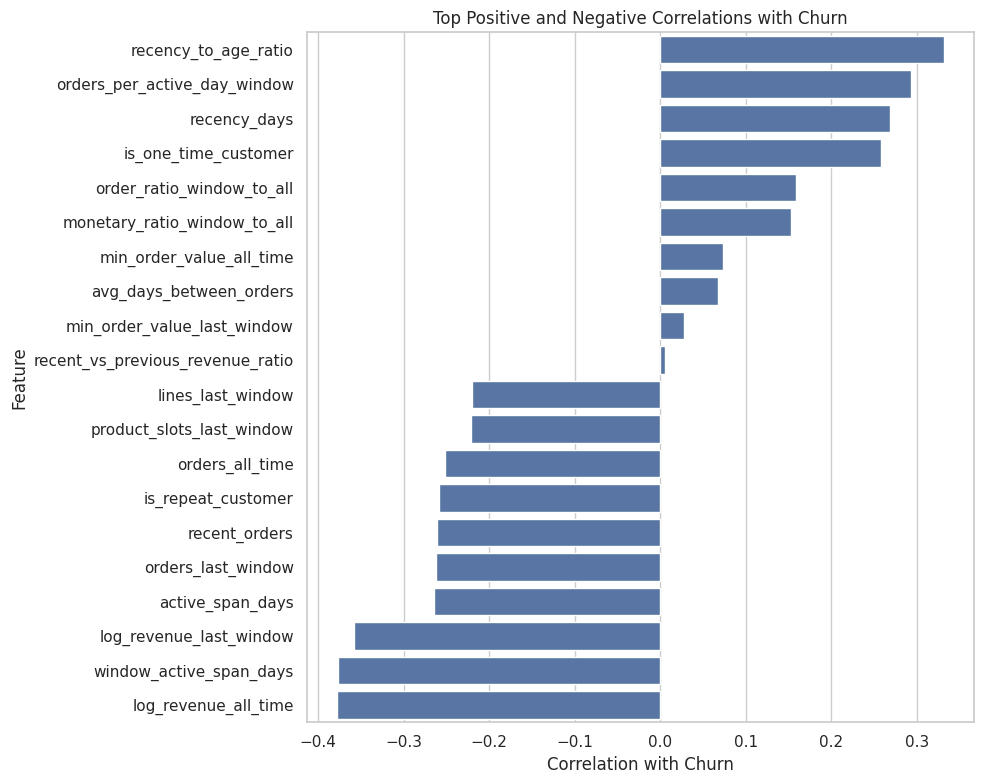

In [34]:
numeric_cols = churn_df.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["future_orders"]]

correlation_with_churn = (
    churn_df[numeric_cols]
    .corr()["churn"]
    .drop("churn")
    .sort_values(ascending=False)
    .reset_index()
)
correlation_with_churn.columns = ["feature", "correlation_with_churn"]

display(correlation_with_churn)

top_corr = pd.concat([correlation_with_churn.head(10), correlation_with_churn.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_corr, x="correlation_with_churn", y="feature")
plt.title("Top Positive and Negative Correlations with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

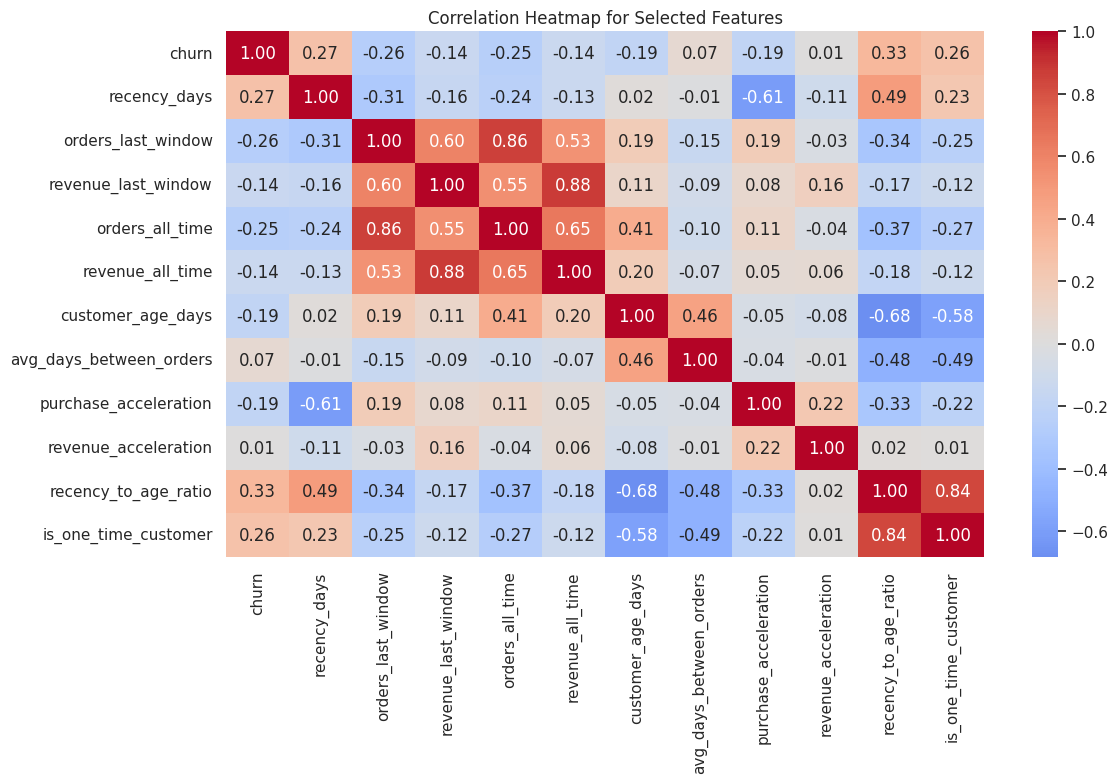

In [35]:
heatmap_features = [
    "churn",
    "recency_days",
    "orders_last_window",
    "revenue_last_window",
    "orders_all_time",
    "revenue_all_time",
    "customer_age_days",
    "avg_days_between_orders",
    "purchase_acceleration",
    "revenue_acceleration",
    "recency_to_age_ratio",
    "is_one_time_customer"
]

heatmap_features = [col for col in heatmap_features if col in churn_df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(
    churn_df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap for Selected Features")
plt.tight_layout()
plt.show()

In [36]:
unique_snapshots = np.array(sorted(churn_df["snapshot_date"].unique()))

train_cutoff_index = int(len(unique_snapshots) * 0.70)
valid_cutoff_index = int(len(unique_snapshots) * 0.85)

train_snapshots = unique_snapshots[:train_cutoff_index]
valid_snapshots = unique_snapshots[train_cutoff_index:valid_cutoff_index]
test_snapshots = unique_snapshots[valid_cutoff_index:]

train_df = churn_df[churn_df["snapshot_date"].isin(train_snapshots)].copy()
valid_df = churn_df[churn_df["snapshot_date"].isin(valid_snapshots)].copy()
test_df = churn_df[churn_df["snapshot_date"].isin(test_snapshots)].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

print("Train snapshot range:", train_df["snapshot_date"].min(), "to", train_df["snapshot_date"].max())
print("Validation snapshot range:", valid_df["snapshot_date"].min(), "to", valid_df["snapshot_date"].max())
print("Test snapshot range:", test_df["snapshot_date"].min(), "to", test_df["snapshot_date"].max())

print("Train churn rate:", train_df["churn"].mean())
print("Validation churn rate:", valid_df["churn"].mean())
print("Test churn rate:", test_df["churn"].mean())

Train shape: (34104, 54)
Validation shape: (5708, 54)
Test shape: (8267, 54)
Train snapshot range: 2010-06-01 07:45:00 to 2011-04-01 07:45:00
Validation snapshot range: 2011-05-01 07:45:00 to 2011-06-01 07:45:00
Test snapshot range: 2011-07-01 07:45:00 to 2011-09-01 07:45:00
Train churn rate: 0.5262139338494018
Validation churn rate: 0.5110371408549405
Test churn rate: 0.438853272045482


In [37]:
target_col = "churn"

selected_feature_cols = [
    "orders_last_window",
    "revenue_last_window",
    "quantity_last_window",
    "product_slots_last_window",
    "lines_last_window",
    "avg_order_value_last_window",
    "max_order_value_last_window",
    "min_order_value_last_window",
    "std_order_value_last_window",
    "avg_quantity_per_order_last_window",
    "avg_products_per_order_last_window",
    "avg_lines_per_order_last_window",
    "country",
    "orders_all_time",
    "revenue_all_time",
    "quantity_all_time",
    "product_slots_all_time",
    "lines_all_time",
    "avg_order_value_all_time",
    "max_order_value_all_time",
    "min_order_value_all_time",
    "std_order_value_all_time",
    "recent_orders",
    "recent_revenue",
    "previous_orders",
    "previous_revenue",
    "recency_days",
    "customer_age_days",
    "active_span_days",
    "window_active_span_days",
    "avg_days_between_orders",
    "order_frequency_all_time",
    "revenue_per_day_all_time",
    "orders_per_active_day_window",
    "revenue_per_order_all_time",
    "quantity_per_order_all_time",
    "monetary_ratio_window_to_all",
    "order_ratio_window_to_all",
    "purchase_acceleration",
    "revenue_acceleration",
    "recent_vs_previous_order_ratio",
    "recent_vs_previous_revenue_ratio",
    "recency_to_age_ratio",
    "is_one_time_customer",
    "is_repeat_customer",
    "log_revenue_last_window",
    "log_revenue_all_time",
    "log_avg_order_value_last_window",
    "snapshot_month",
    "snapshot_quarter"
]

feature_cols = [col for col in selected_feature_cols if col in churn_df.columns]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

numeric_features = X_train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of selected features:", len(feature_cols))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Number of selected features: 50
Numeric features: ['orders_last_window', 'revenue_last_window', 'quantity_last_window', 'product_slots_last_window', 'lines_last_window', 'avg_order_value_last_window', 'max_order_value_last_window', 'min_order_value_last_window', 'std_order_value_last_window', 'avg_quantity_per_order_last_window', 'avg_products_per_order_last_window', 'avg_lines_per_order_last_window', 'orders_all_time', 'revenue_all_time', 'quantity_all_time', 'product_slots_all_time', 'lines_all_time', 'avg_order_value_all_time', 'max_order_value_all_time', 'min_order_value_all_time', 'std_order_value_all_time', 'recent_orders', 'recent_revenue', 'previous_orders', 'previous_revenue', 'recency_days', 'customer_age_days', 'active_span_days', 'window_active_span_days', 'avg_days_between_orders', 'order_frequency_all_time', 'revenue_per_day_all_time', 'orders_per_active_day_window', 'revenue_per_order_all_time', 'quantity_per_order_all_time', 'monetary_ratio_window_to_all', 'order_ratio_

In [38]:
model_feature_description = pd.DataFrame(
    {
        "feature": feature_cols,
        "type": [
            "numeric" if feature in numeric_features else "categorical"
            for feature in feature_cols
        ]
    }
)

model_feature_description

def make_one_hot_encoder():
    """
    Create a OneHotEncoder with compatibility for different scikit-learn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=10)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")


def make_preprocessor():
    """
    Create a fresh preprocessing object for each model pipeline.
    """
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder())
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return preprocessor


print("Preprocessor is ready.")

Preprocessor is ready.


In [39]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    ),

    "random_forest": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=12,
                    min_samples_leaf=10,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    ),

    "extra_trees": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=300,
                    max_depth=12,
                    min_samples_leaf=10,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
}

try:
    from xgboost import XGBClassifier

    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())
    scale_pos_weight = negative_count / max(positive_count, 1)

    models["xgboost"] = Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                XGBClassifier(
                    n_estimators=400,
                    max_depth=4,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
    print("XGBoost is available and added.")

except Exception as error:
    print("XGBoost is not available. Skipping XGBoost.")
    print(error)

print("Models:")
print(list(models.keys()))

XGBoost is available and added.
Models:
['logistic_regression', 'random_forest', 'extra_trees', 'xgboost']


In [40]:
def evaluate_predictions(y_true, y_proba, threshold=0.5):
    """
    Evaluate predicted probabilities using a fixed threshold.
    """
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    except Exception:
        metrics["roc_auc"] = np.nan

    try:
        metrics["pr_auc"] = average_precision_score(y_true, y_proba)
    except Exception:
        metrics["pr_auc"] = np.nan

    return metrics

In [41]:
model_results = []
fitted_models = {}

for model_name, model_pipeline in models.items():
    print(f"Training model: {model_name}")

    model_pipeline.fit(X_train, y_train)

    valid_proba = model_pipeline.predict_proba(X_valid)[:, 1]
    metrics = evaluate_predictions(y_valid, valid_proba, threshold=0.5)

    row = {"model": model_name}
    row.update(metrics)

    model_results.append(row)
    fitted_models[model_name] = model_pipeline

model_results_df = pd.DataFrame(model_results).sort_values("pr_auc", ascending=False)
model_results_df

Training model: logistic_regression
Training model: random_forest
Training model: extra_trees
Training model: xgboost


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,random_forest,0.725298,0.723863,0.747686,0.735582,0.802055,0.791352
2,extra_trees,0.713735,0.713762,0.734316,0.723893,0.784657,0.769180
3,xgboost,0.703924,0.723010,0.681865,0.701835,0.783440,0.767127
0,logistic_regression,0.706027,0.692931,0.762770,0.726175,0.780134,0.759908


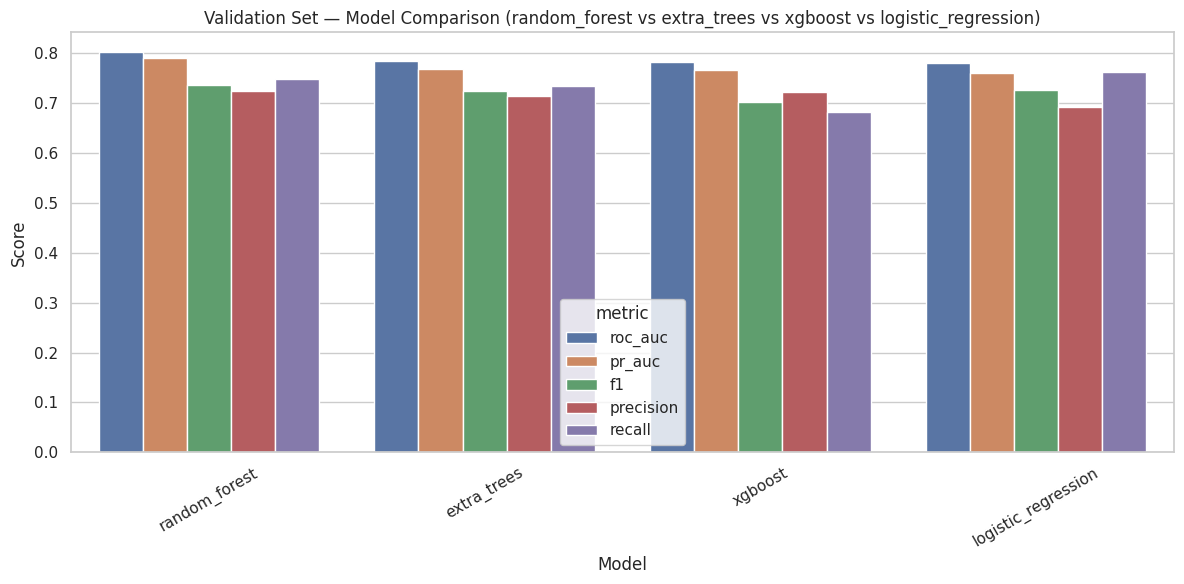

In [42]:
model_results_long = model_results_df.melt(
    id_vars="model",
    value_vars=["roc_auc", "pr_auc", "f1", "precision", "recall"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=model_results_long, x="model", y="score", hue="metric")
model_labels_val = " vs ".join(model_results_df["model"].tolist())
plt.title(f"Validation Set — Model Comparison ({model_labels_val})")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [43]:
BEST_MODEL_METRIC = "pr_auc"

best_model_name = (
    model_results_df
    .sort_values(BEST_MODEL_METRIC, ascending=False)
    .iloc[0]["model"]
)

best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)
print("Selection metric:", BEST_MODEL_METRIC)

model_results_df

Best model: random_forest
Selection metric: pr_auc


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,random_forest,0.725298,0.723863,0.747686,0.735582,0.802055,0.791352
2,extra_trees,0.713735,0.713762,0.734316,0.723893,0.784657,0.769180
3,xgboost,0.703924,0.723010,0.681865,0.701835,0.783440,0.767127
0,logistic_regression,0.706027,0.692931,0.762770,0.726175,0.780134,0.759908


In [44]:
valid_proba = best_model.predict_proba(X_valid)[:, 1]

threshold_rows = []

for threshold in np.arange(0.05, 0.96, 0.01):
    threshold = round(float(threshold), 2)
    valid_pred_threshold = (valid_proba >= threshold).astype(int)

    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_valid, valid_pred_threshold, zero_division=0),
            "recall": recall_score(y_valid, valid_pred_threshold, zero_division=0),
            "f1": f1_score(y_valid, valid_pred_threshold, zero_division=0),
            "accuracy": accuracy_score(y_valid, valid_pred_threshold)
        }
    )

threshold_df = pd.DataFrame(threshold_rows)

best_threshold = (
    threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]["threshold"]
)

print("Best threshold selected from validation set:", best_threshold)
threshold_df.sort_values("f1", ascending=False).head(10)

Best threshold selected from validation set: 0.39


,threshold,precision,recall,f1,accuracy
34,0.39,0.657915,0.884813,0.754678,0.706027
37,0.42,0.674601,0.854988,0.754158,0.715137
35,0.40,0.662341,0.874871,0.753914,0.708129
36,0.41,0.668346,0.864244,0.753775,0.711458
38,0.43,0.680287,0.844703,0.753632,0.717765
33,0.38,0.653159,0.889613,0.753266,0.702172
31,0.36,0.642233,0.907096,0.752025,0.694289
32,0.37,0.647292,0.897155,0.752011,0.697617
30,0.35,0.638696,0.913267,0.751693,0.691661
39,0.44,0.684329,0.832362,0.751121,0.718115


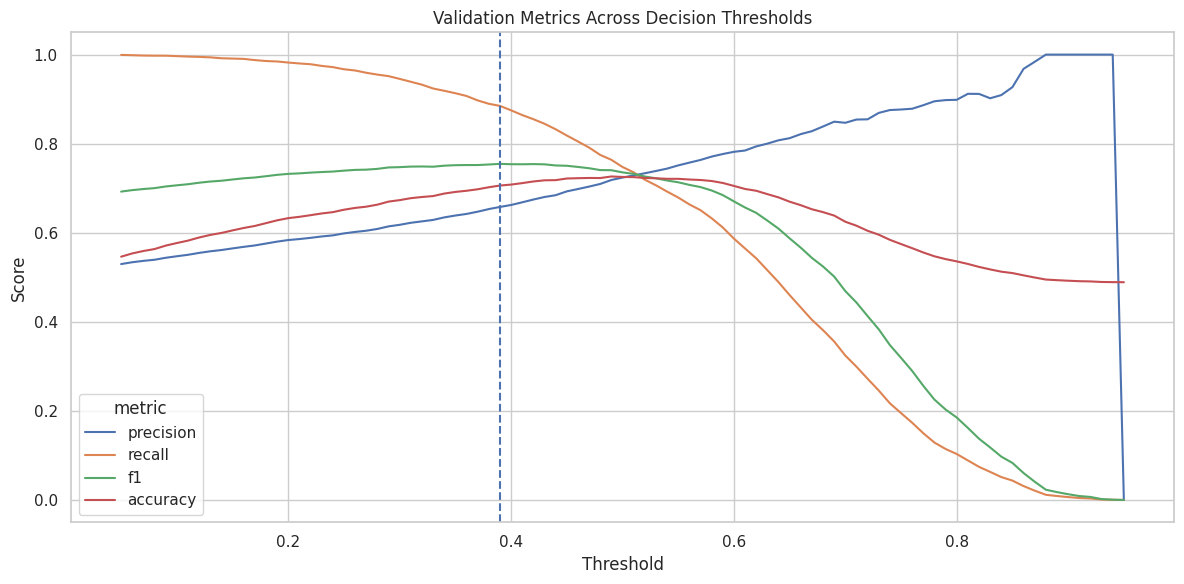

In [45]:
threshold_long = threshold_df.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1", "accuracy"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=threshold_long, x="threshold", y="score", hue="metric")
plt.axvline(best_threshold, linestyle="--")
plt.title("Validation Metrics Across Decision Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [46]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = evaluate_predictions(y_test, test_proba, threshold=best_threshold)

print("Final test metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nClassification report:")
print(classification_report(y_test, test_pred, zero_division=0))

Final test metrics:
accuracy: 0.6753
precision: 0.5926
recall: 0.8327
f1: 0.6924
roc_auc: 0.7722
pr_auc: 0.6960

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.66      4639
           1       0.59      0.83      0.69      3628

    accuracy                           0.68      8267
   macro avg       0.70      0.69      0.67      8267
weighted avg       0.71      0.68      0.67      8267



## All-Models Final Test Comparison

Evaluate **every** trained model on the held-out test set so the comparison is not limited to the validation-set winner alone.

In [47]:
# ── Evaluate ALL models on final test set ───────────────────────────────────
all_test_results = []

for model_name, model_pipeline in fitted_models.items():
    test_proba_m = model_pipeline.predict_proba(X_test)[:, 1]

    # Use the same optimal threshold that was tuned on the best model's
    # validation set.  Each model is evaluated at this threshold so the
    # comparison is apples-to-apples.
    metrics_m = evaluate_predictions(y_test, test_proba_m, threshold=best_threshold)
    row = {"model": model_name}
    row.update(metrics_m)
    all_test_results.append(row)

all_test_results_df = (
    pd.DataFrame(all_test_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

print("All-models final test comparison (threshold =", best_threshold, ")")
display(all_test_results_df)


All-models final test comparison (threshold = 0.39 )


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,extra_trees,0.681626,0.600444,0.820562,0.693454,0.774115,0.700230
1,logistic_regression,0.671465,0.585940,0.856946,0.695993,0.773745,0.697068
2,random_forest,0.675336,0.592585,0.832690,0.692413,0.772178,0.696017
3,xgboost,0.689851,0.663692,0.594542,0.627217,0.765143,0.695407


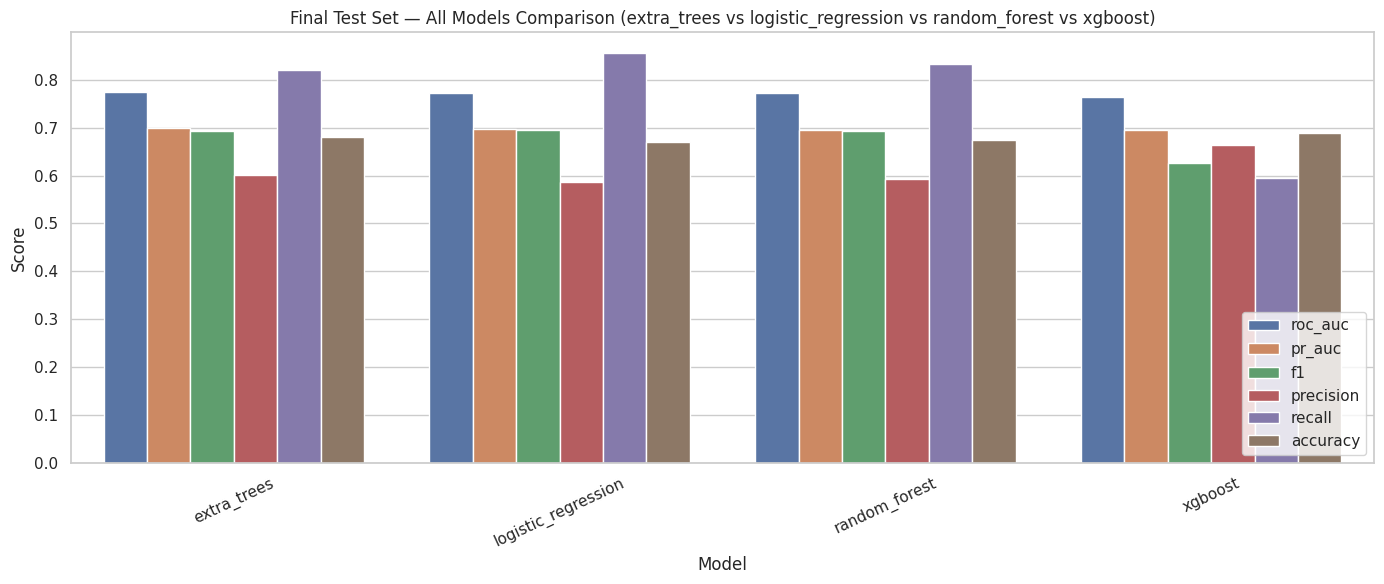

In [48]:
# ── Chart: all models on test set ───────────────────────────────────────────
test_results_long = all_test_results_df.melt(
    id_vars="model",
    value_vars=["roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy"],
    var_name="metric",
    value_name="score"
)

model_labels = " vs ".join(all_test_results_df["model"].tolist())
chart_title = f"Final Test Set — All Models Comparison ({model_labels})"

plt.figure(figsize=(14, 6))
sns.barplot(data=test_results_long, x="model", y="score", hue="metric")
plt.title(chart_title)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [49]:
# ── Per-model classification report on test set ─────────────────────────────
from sklearn.metrics import classification_report as clf_report

for model_name, model_pipeline in fitted_models.items():
    test_proba_m = model_pipeline.predict_proba(X_test)[:, 1]
    test_pred_m  = (test_proba_m >= best_threshold).astype(int)

    print(f"\n{'='*60}")
    print(f"Model: {model_name}  |  threshold = {best_threshold}")
    print(f"{'='*60}")
    print(clf_report(y_test, test_pred_m, zero_division=0,
                     target_names=["not_churn", "churn"]))



Model: logistic_regression  |  threshold = 0.39
              precision    recall  f1-score   support

   not_churn       0.82      0.53      0.64      4639
       churn       0.59      0.86      0.70      3628

    accuracy                           0.67      8267
   macro avg       0.71      0.69      0.67      8267
weighted avg       0.72      0.67      0.67      8267


Model: random_forest  |  threshold = 0.39
              precision    recall  f1-score   support

   not_churn       0.81      0.55      0.66      4639
       churn       0.59      0.83      0.69      3628

    accuracy                           0.68      8267
   macro avg       0.70      0.69      0.67      8267
weighted avg       0.71      0.68      0.67      8267


Model: extra_trees  |  threshold = 0.39
              precision    recall  f1-score   support

   not_churn       0.80      0.57      0.67      4639
       churn       0.60      0.82      0.69      3628

    accuracy                           0.68      

,pred_not_churn,pred_churn
actual_not_churn,2562,2077
actual_churn,607,3021


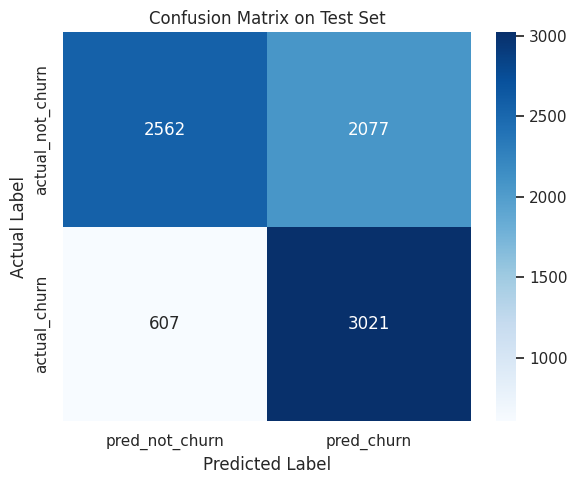

In [50]:
conf_matrix = confusion_matrix(y_test, test_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["actual_not_churn", "actual_churn"],
    columns=["pred_not_churn", "pred_churn"]
)

display(conf_matrix_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

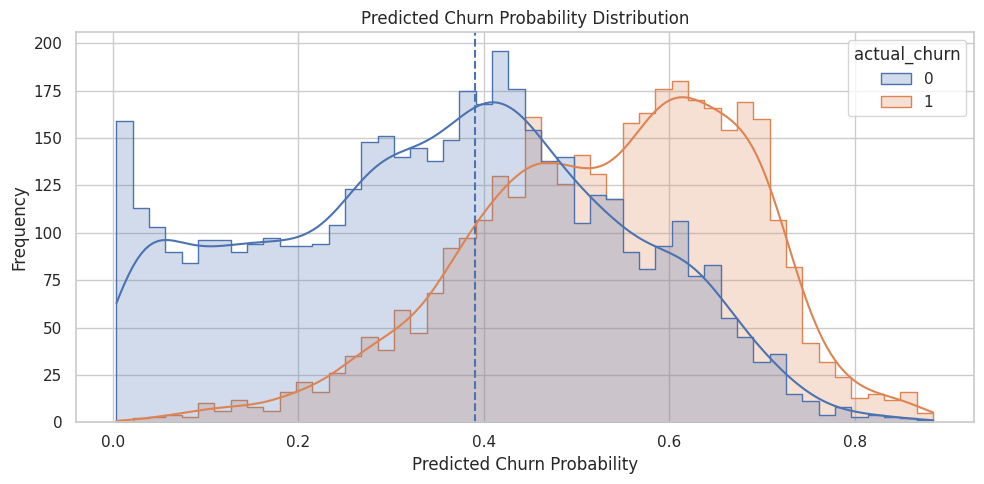

In [51]:
test_prediction_analysis = pd.DataFrame(
    {
        "actual_churn": y_test.values,
        "predicted_churn_probability": test_proba,
        "predicted_churn": test_pred
    }
)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=test_prediction_analysis,
    x="predicted_churn_probability",
    hue="actual_churn",
    bins=50,
    kde=True,
    element="step"
)
plt.axvline(best_threshold, linestyle="--")
plt.title("Predicted Churn Probability Distribution")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [52]:
test_predictions = test_df[["customer_id", "snapshot_date", "churn"]].copy()
test_predictions["predicted_churn_probability"] = test_proba
test_predictions["predicted_churn"] = test_pred
test_predictions["best_threshold"] = best_threshold

prediction_path = OUTPUT_DIR / "test_predictions.csv"
test_predictions.to_csv(prediction_path, index=False)

print("Saved test predictions to:", prediction_path)
test_predictions.head()

Saved test predictions to: /kaggle/working/test_predictions.csv


,customer_id,snapshot_date,churn,predicted_churn_probability,predicted_churn,best_threshold
39812,12346,2011-07-01 07:45:00,1,0.626828,1,0.39
39813,12347,2011-07-01 07:45:00,0,0.217073,0,0.39
39814,12348,2011-07-01 07:45:00,0,0.452659,1,0.39
39815,12350,2011-07-01 07:45:00,1,0.683627,1,0.39
39816,12352,2011-07-01 07:45:00,0,0.480833,1,0.39


In [53]:
sample_size = min(3000, len(X_test))

X_test_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_test_sample = y_test.loc[X_test_sample.index]

perm_result = permutation_importance(
    best_model,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="average_precision",
    n_jobs=-1
)

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }
).sort_values("importance_mean", ascending=False)

feature_importance_path = OUTPUT_DIR / "feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

feature_importance_df.head(20)

,feature,importance_mean,importance_std
31,order_frequency_all_time,0.004818,0.001739
32,revenue_per_day_all_time,0.002971,0.001601
17,lines_all_time,0.002625,0.001027
48,snapshot_month,0.002330,0.000731
29,window_active_span_days,0.000654,0.001124
35,quantity_per_order_all_time,0.000647,0.000502
22,recent_orders,0.000631,0.000450
0,orders_last_window,0.000589,0.000866
36,monetary_ratio_window_to_all,0.000527,0.000901
11,avg_lines_per_order_last_window,0.000479,0.000174


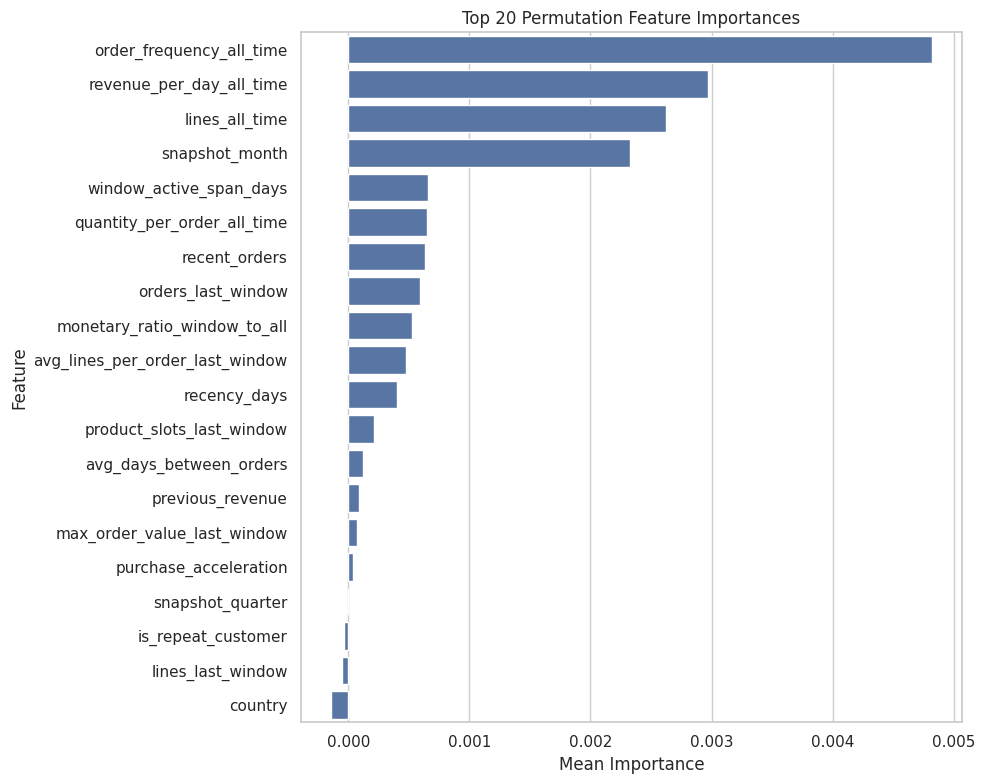

In [54]:
top_importance = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_importance, x="importance_mean", y="feature")
plt.title("Top 20 Permutation Feature Importances")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [55]:
X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

final_model = clone(models[best_model_name])
final_model.fit(X_train_valid, y_train_valid)

final_test_proba = final_model.predict_proba(X_test)[:, 1]
final_test_pred = (final_test_proba >= best_threshold).astype(int)

final_test_metrics = evaluate_predictions(y_test, final_test_proba, threshold=best_threshold)

print("Final model retrained on train + validation.")
print("Final test metrics after retraining:")
for key, value in final_test_metrics.items():
    print(f"{key}: {value:.4f}")

model_path = OUTPUT_DIR / "online_retail_ii_churn_model.joblib"
joblib.dump(final_model, model_path)

metadata = {
    "project_name": "Online Retail II Customer Churn Prediction",
    "created_at": datetime.utcnow().isoformat(),
    "dataset": "Online Retail II UCI",
    "dataset_type": "static historical transaction dataset",
    "modeling_type": "historical batch churn prediction",
    "best_model": best_model_name,
    "best_model_metric": BEST_MODEL_METRIC,
    "best_threshold": float(best_threshold),
    "churn_window_days": CHURN_WINDOW_DAYS,
    "history_window_days": HISTORY_WINDOW_DAYS,
    "snapshot_frequency": SNAPSHOT_FREQUENCY,
    "feature_columns": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "train_rows": int(len(train_df)),
    "valid_rows": int(len(valid_df)),
    "test_rows": int(len(test_df)),
    "train_churn_rate": float(y_train.mean()),
    "valid_churn_rate": float(y_valid.mean()),
    "test_churn_rate": float(y_test.mean()),
    "validation_model_comparison": model_results_df.to_dict(orient="records"),
    "test_metrics_before_retraining": test_metrics,
    "test_metrics_after_retraining": final_test_metrics
}

metadata_path = OUTPUT_DIR / "model_metadata.json"
with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

metrics_path = OUTPUT_DIR / "model_comparison.csv"
model_results_df.to_csv(metrics_path, index=False)

threshold_path = OUTPUT_DIR / "threshold_tuning.csv"
threshold_df.to_csv(threshold_path, index=False)

print("Saved model to:", model_path)
print("Saved metadata to:", metadata_path)
print("Saved model comparison to:", metrics_path)
print("Saved threshold tuning result to:", threshold_path)

Final model retrained on train + validation.
Final test metrics after retraining:
accuracy: 0.6797
precision: 0.5947
recall: 0.8479
f1: 0.6991
roc_auc: 0.7848
pr_auc: 0.7138
Saved model to: /kaggle/working/online_retail_ii_churn_model.joblib
Saved metadata to: /kaggle/working/model_metadata.json
Saved model comparison to: /kaggle/working/model_comparison.csv
Saved threshold tuning result to: /kaggle/working/threshold_tuning.csv


In [56]:
latest_historical_snapshot_date = invoice_df["invoice_date"].max() - pd.Timedelta(days=CHURN_WINDOW_DAYS)

latest_scoring_df = build_features_for_snapshot(
    invoice_table=invoice_df,
    snapshot_date=latest_historical_snapshot_date,
    churn_window_days=CHURN_WINDOW_DAYS,
    history_window_days=HISTORY_WINDOW_DAYS
)

latest_X = latest_scoring_df[feature_cols].copy()

latest_scoring_df["predicted_churn_probability"] = final_model.predict_proba(latest_X)[:, 1]
latest_scoring_df["predicted_churn"] = (
    latest_scoring_df["predicted_churn_probability"] >= best_threshold
).astype(int)

latest_customer_scores = latest_scoring_df[
    [
        "customer_id",
        "snapshot_date",
        "country",
        "orders_last_window",
        "revenue_last_window",
        "recency_days",
        "customer_age_days",
        "predicted_churn_probability",
        "predicted_churn"
    ]
].sort_values("predicted_churn_probability", ascending=False)

latest_scores_path = OUTPUT_DIR / "latest_historical_customer_churn_scores.csv"
latest_customer_scores.to_csv(latest_scores_path, index=False)

print("Latest historical snapshot date:", latest_historical_snapshot_date)
print("Saved latest historical customer scores to:", latest_scores_path)
latest_customer_scores.head(20)

Latest historical snapshot date: 2011-09-10 12:50:00
Saved latest historical customer scores to: /kaggle/working/latest_historical_customer_churn_scores.csv


,customer_id,snapshot_date,country,orders_last_window,revenue_last_window,recency_days,customer_age_days,predicted_churn_probability,predicted_churn
411,13185,2011-09-10 12:50:00,United Kingdom,1,71.40,177,177,0.871063,1
2547,17747,2011-09-10 12:50:00,United Kingdom,1,71.40,22,22,0.865966,1
1438,15313,2011-09-10 12:50:00,United Kingdom,1,52.00,19,19,0.856176,1
723,13841,2011-09-10 12:50:00,United Kingdom,1,85.00,162,162,0.856082,1
1583,15668,2011-09-10 12:50:00,United Kingdom,1,76.32,127,127,0.853252,1
507,13391,2011-09-10 12:50:00,United Kingdom,1,59.80,113,113,0.841738,1
1328,15098,2011-09-10 12:50:00,United Kingdom,3,39916.50,91,91,0.841279,1
381,13120,2011-09-10 12:50:00,United Kingdom,1,30.60,148,148,0.837152,1
398,13147,2011-09-10 12:50:00,United Kingdom,1,118.80,9,9,0.835734,1
2660,18013,2011-09-10 12:50:00,United Kingdom,2,187.29,64,64,0.829569,1


In [57]:
model_card = f"""
# Online Retail II Customer Churn Prediction Model Card

## Objective

This project builds a historical batch churn prediction model using the Online Retail II UCI dataset.

The goal is to predict whether a customer is likely to churn based on historical purchase behavior.

## Dataset

Dataset used: Online Retail II UCI

The dataset contains historical transaction records from an online retail store. The main columns include invoice number, stock code, description, quantity, invoice date, unit price, customer ID, and country.

## Important Context

This is not a real-time dataset. The dataset contains historical transactions from the past.

Therefore, this project should be interpreted as a historical churn prediction simulation, not a live 2026 churn prediction system.

## Churn Definition

A customer is labeled as churned if they do not make another purchase within {CHURN_WINDOW_DAYS} days after a given snapshot date.

- churn = 1: customer did not purchase again within the future churn window
- churn = 0: customer purchased again within the future churn window

## Feature Window

The model uses customer behavior from the previous {HISTORY_WINDOW_DAYS} days before each snapshot date.

## Feature Groups

The model uses behavioral features such as:

- Recency features
- Frequency features
- Monetary features
- Customer lifecycle features
- Purchase acceleration features
- Country-level categorical information
- Snapshot month and quarter

## Modeling Approach

A rolling snapshot method is used.

For each snapshot date:

- Only transactions before or on the snapshot date are used as model features
- Transactions after the snapshot date are used only to define the churn label

This avoids data leakage and simulates a real-world batch prediction process.

## Data Split

The dataset is split by snapshot date:

- Training set: earliest snapshots
- Validation set: middle snapshots
- Test set: latest snapshots

This temporal split better represents future prediction compared to random splitting.

## Best Model

Best selected model: {best_model_name}

Selection metric: {BEST_MODEL_METRIC}

Decision threshold selected on validation set: {best_threshold}

## Final Test Metrics

{json.dumps(final_test_metrics, indent=4)}

## Limitations

- The dataset is historical and may not represent current e-commerce behavior.
- The model does not use marketing campaign data, customer demographic data, or web behavior data.
- The model is predictive, not causal.
- The churn label depends on the available observation window.
- Real-world deployment would require newer transaction data.

## Recommended Use

This model can be used to understand historical churn behavior and simulate customer retention targeting.
"""

model_card_path = OUTPUT_DIR / "model_card.md"
with open(model_card_path, "w") as file:
    file.write(model_card)

print("Saved model card to:", model_card_path)
print(model_card)

print("\nGenerated output files:")
for file_path in sorted(OUTPUT_DIR.glob("*")):
    if file_path.is_file():
        print(file_path)

Saved model card to: /kaggle/working/model_card.md

# Online Retail II Customer Churn Prediction Model Card

## Objective

This project builds a historical batch churn prediction model using the Online Retail II UCI dataset.

The goal is to predict whether a customer is likely to churn based on historical purchase behavior.

## Dataset

Dataset used: Online Retail II UCI

The dataset contains historical transaction records from an online retail store. The main columns include invoice number, stock code, description, quantity, invoice date, unit price, customer ID, and country.

## Important Context

This is not a real-time dataset. The dataset contains historical transactions from the past.

Therefore, this project should be interpreted as a historical churn prediction simulation, not a live 2026 churn prediction system.

## Churn Definition

A customer is labeled as churned if they do not make another purchase within 90 days after a given snapshot date.

- churn = 1: customer did not 